# 1. Import neccessary libraries

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
# from scipy.cluster.hierarchy import dendrogram, linkage
# from scipy.spatial.distance import squareform
from sklearn.model_selection import train_test_split
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.neighbors import NearestNeighbors
from random import sample
from math import isnan
import warnings

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

# 2. Data preprocessing

## 2.1 Load datasets

In [261]:
global_data = pd.read_parquet('/Users/mac/learning/trading-pipeline/ml/data/ds1_global_data.parquet')
# quarter_data = pd.read_parquet('/Users/mac/learning/trading-pipeline/ml/data/ds2_quarter_data.parquet')

In [262]:
global_data.head()

,ticker,mean_daily_return,mean_momentum_20d,mean_close_vs_sma200,mean_stock_vs_market,beta_global,mean_volatility_20d,mean_sharpe_20d,worst_drawdown,mean_atr_14,...,mean_rsi_14,mean_adx_14,mean_macd_hist,mean_stoch_k,mean_bb_width,mean_liquidity_20d,mean_volume_ratio,mean_price_pos_20d,return_skewness,return_kurtosis
0,AAPL,0.0007,0.0153,0.0537,0.0001,1.2106,0.0171,1.3189,-0.3343,5.2651,...,54.2548,22.5954,0.0444,59.1044,0.1185,12024456575.2846,1.0116,0.6071,1.0468,14.2810
1,ABBV,0.0007,0.0131,0.0616,0.0001,0.3785,0.0158,1.2775,-0.2146,4.3975,...,54.0229,27.7884,-0.0644,55.4352,0.1161,1195324899.3901,1.0160,0.5578,-1.3934,10.4699
2,AMZN,0.0010,0.0232,0.0693,0.0004,1.3583,0.0200,1.0745,-0.3088,5.5864,...,53.4888,21.5816,0.0939,57.6415,0.1276,8885106527.7359,1.0185,0.5992,0.4448,5.3031
3,AXP,0.0011,0.0283,0.1108,0.0005,1.3188,0.0179,1.4466,-0.2899,6.9685,...,55.4848,20.8174,0.0580,62.0397,0.1212,809776313.2010,1.0100,0.6426,0.6255,9.5002
4,BA,0.0005,0.0150,0.0479,-0.0000,1.1278,0.0212,0.8436,-0.4831,5.5515,...,52.0128,25.6381,-0.0483,50.6150,0.1533,1670663097.7731,1.0249,0.5046,0.3345,8.4168


In [263]:
global_data.shape

(48, 21)

In [264]:
global_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticker                 48 non-null     object 
 1   mean_daily_return      48 non-null     float64
 2   mean_momentum_20d      48 non-null     float64
 3   mean_close_vs_sma200   48 non-null     float64
 4   mean_stock_vs_market   48 non-null     float64
 5   beta_global            48 non-null     float64
 6   mean_volatility_20d    48 non-null     float64
 7   mean_sharpe_20d        48 non-null     float64
 8   worst_drawdown         48 non-null     float64
 9   mean_atr_14            48 non-null     float64
 10  mean_volatility_ratio  48 non-null     float64
 11  mean_rsi_14            48 non-null     float64
 12  mean_adx_14            48 non-null     float64
 13  mean_macd_hist         48 non-null     float64
 14  mean_stoch_k           48 non-null     float64
 15  mean_bb_

In [265]:
numeric_cols = global_data.select_dtypes(include=[np.number]).columns.tolist()

# Separate features and labels
tickers = global_data['ticker']
features = global_data.drop(columns=['ticker'])

## 2.2 Exploratory Data Analysis ("Data Health Check")
Goal: Understand the raw data's shape and quality before touching it

### 2.2.1 Zero variance handling
Why should we do it?
<br>&rarr; If a column is all zeros, plotting it or checking skewness is a waste of time. We should remove it before doing anything deep analysis

In [266]:
def remove_zero_variance(data):
    variances = data.var()
    zero_var_features = variances[variances == 0].index.tolist()
    
    numeric_cols = []
    if zero_var_features:
        print(f"Found {len(zero_var_features)} features with zero variance")
        numeric_cols = [col for col in data.columns if col not in zero_var_features]
        print(f"Remaining features: {len(numeric_cols)}")
    else:
        print("No zero variance features found")
    
    return numeric_cols

In [267]:
column_to_remove = remove_zero_variance(features)

No zero variance features found


### 2.2.2 Outlier Detection

In [268]:
def IQR(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    upper = df[variable].quantile(0.75) + (IQR * 1.5)
    lower = df[variable].quantile(0.25) - (IQR * 1.5)
    return upper, lower

def outliers_detection(data):
    outlier = []
    for var in data.columns:
        upper, lower = IQR(data, var)
        if data[var].max() > (upper + (upper - lower) * 1.5):
            outlier.append(var)
            print(f"{var} has outliers > 1.5IQR {data[var].max():.2f}")
        elif data[var].min() < (lower - (upper - lower) * 1.5):
            outlier.append(var)
            print(f"{var} has outliers < 1.5IQR {data[var].min():.2f}")
            
    return outlier

In [269]:
outliers_list = outliers_detection(features)

mean_macd_hist has outliers < 1.5IQR -2.39
mean_liquidity_20d has outliers > 1.5IQR 38372281288.31
return_skewness has outliers < 1.5IQR -13.91
return_kurtosis has outliers > 1.5IQR 224.00


### 2.2.3 Multicollinearity Check
Identify which features are duplicates so we know what PCA needs to fix later

In [270]:
def correlation_analysis(data, corr_threshold):
    corr_matrix = data.corr()

    plt.figure(figsize=(20, 16))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > corr_threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_val
                ))
    
    return high_corr_pairs

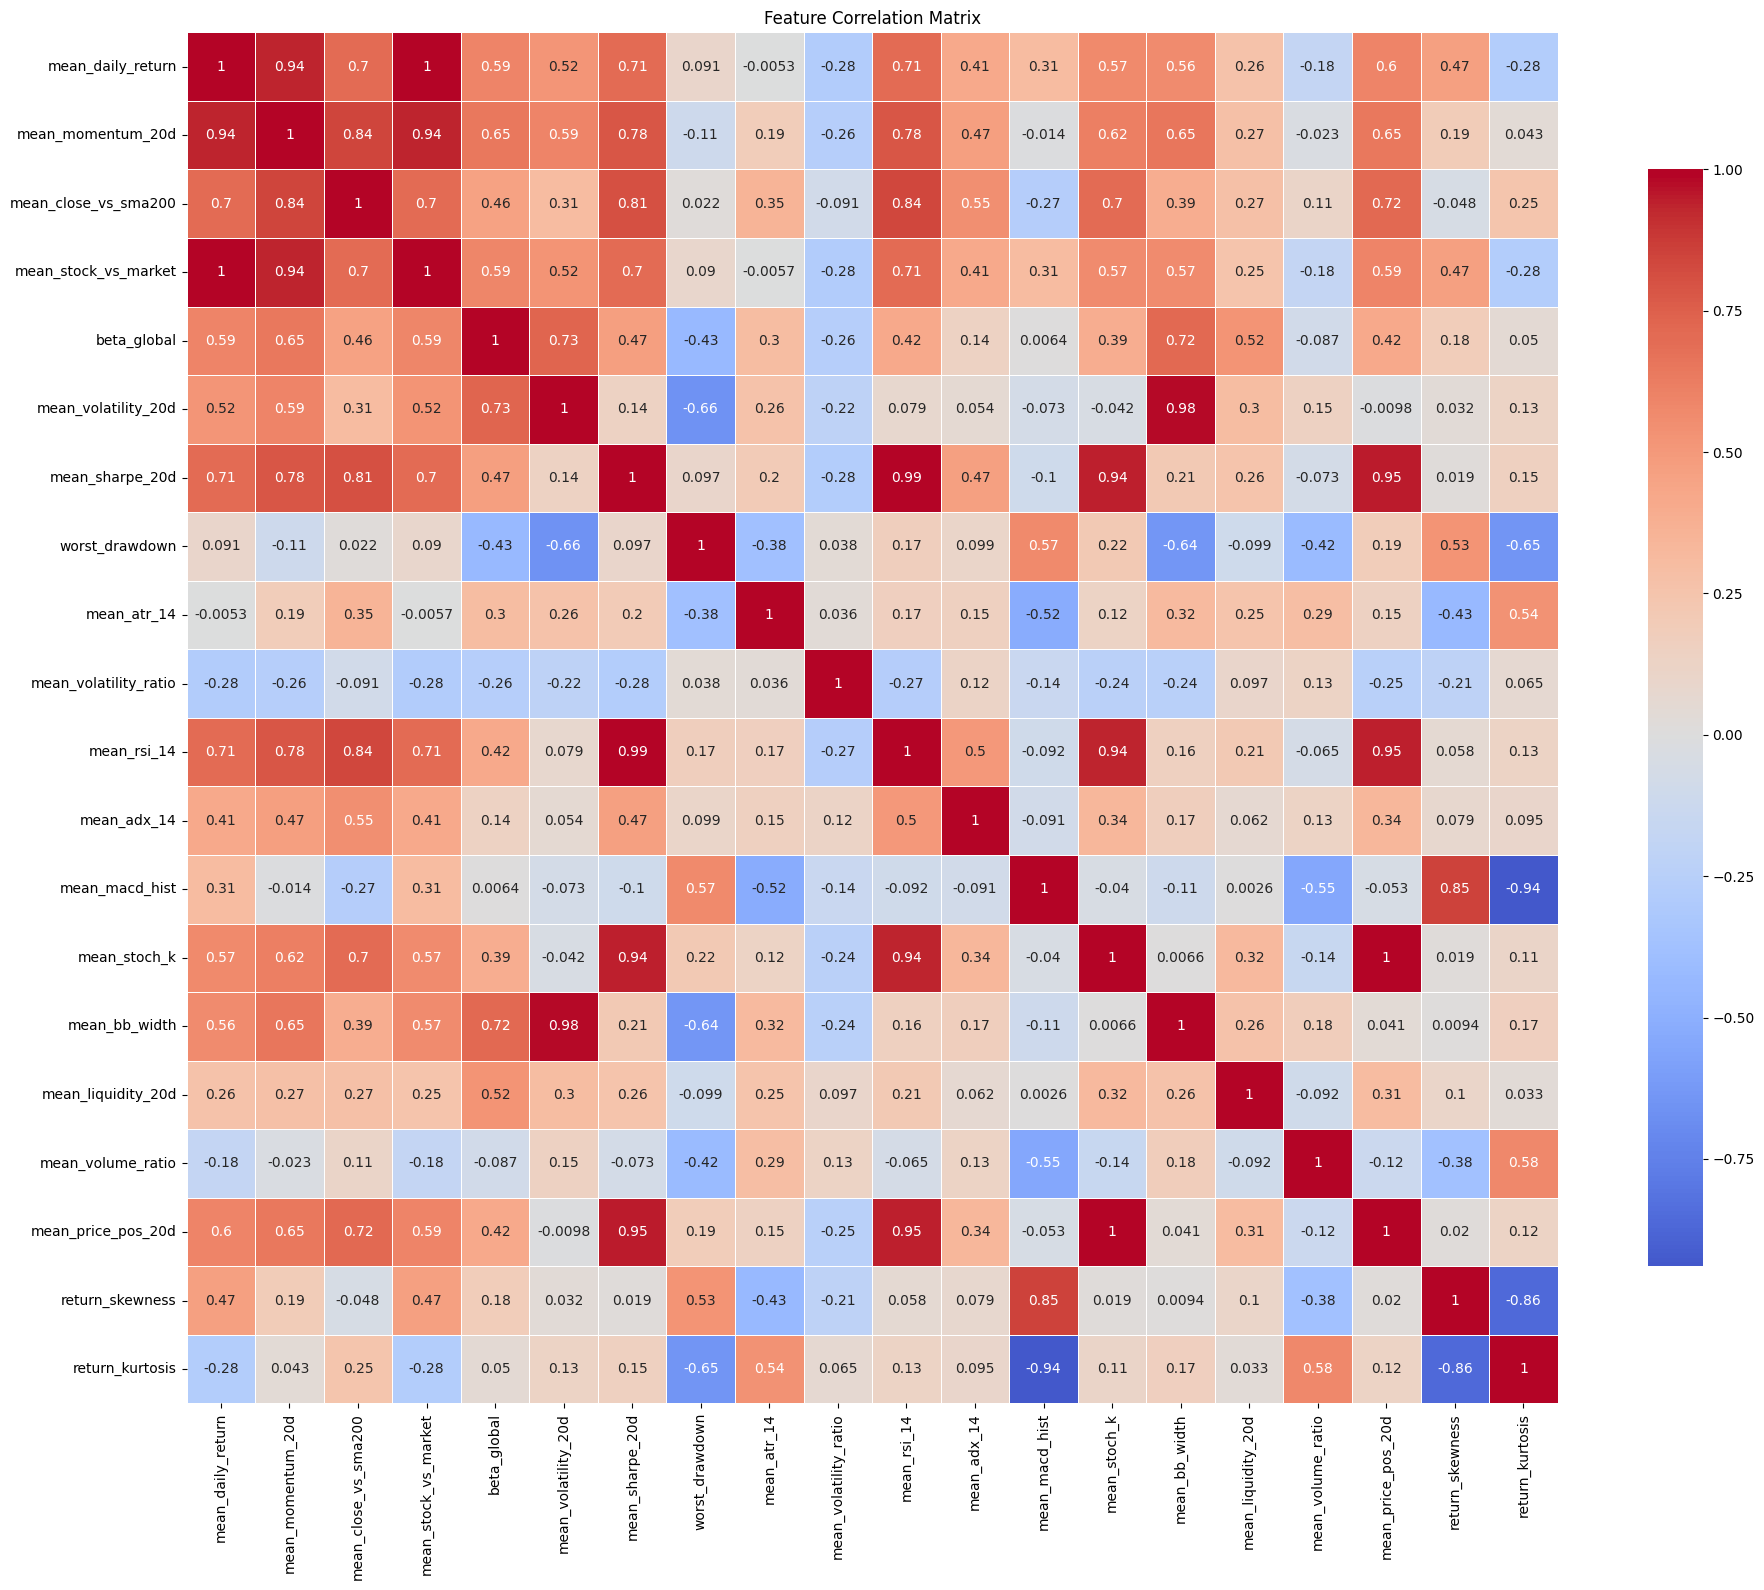

In [271]:
high_corr_pairs = correlation_analysis(features, 0.8)

Need some comments here, will comeback later

## 2.3 Feature Preprocessing ("Data Cleanup")

### 2.3.1 Skewness correction

In [277]:
def skewness_analysis(data, skew_threshold):
        
    skewness = data.skew().sort_values(ascending=False)
    skew_data = []
    normal_data = []

    for feat, skew_val in skewness.items():
        if skew_val > skew_threshold or skew_val < - skew_threshold:
            skew_data.append(feat)
        else:
            normal_data.append(feat)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=skewness.values, y=skewness.index)
    plt.axvline(x=skew_threshold, color='r', linestyle='--', linewidth=1, label=f'High Positive Skew (+{skew_threshold})')
    plt.axvline(x=-skew_threshold, color='r', linestyle='--', linewidth=1, label=f'High Negative Skew (-{skew_threshold})')
    plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    plt.title('Feature Skewness Ranking', fontsize=15)
    plt.xlabel('Skewness Coefficient')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return skew_data, normal_data

def skew_transformation(data, skew_list):
    """
    Apply transformation for highly skewed data
    """
    data_transformed = data.copy()

    for feat in skew_list:
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        data_transformed[feat] = pt.fit_transform(data[[feat]]).flatten()
    
    print(f"Applied Yeo-Johnson transformation for {len(skew_list)} values")

    return data_transformed

In [278]:
skew_threshold = 1

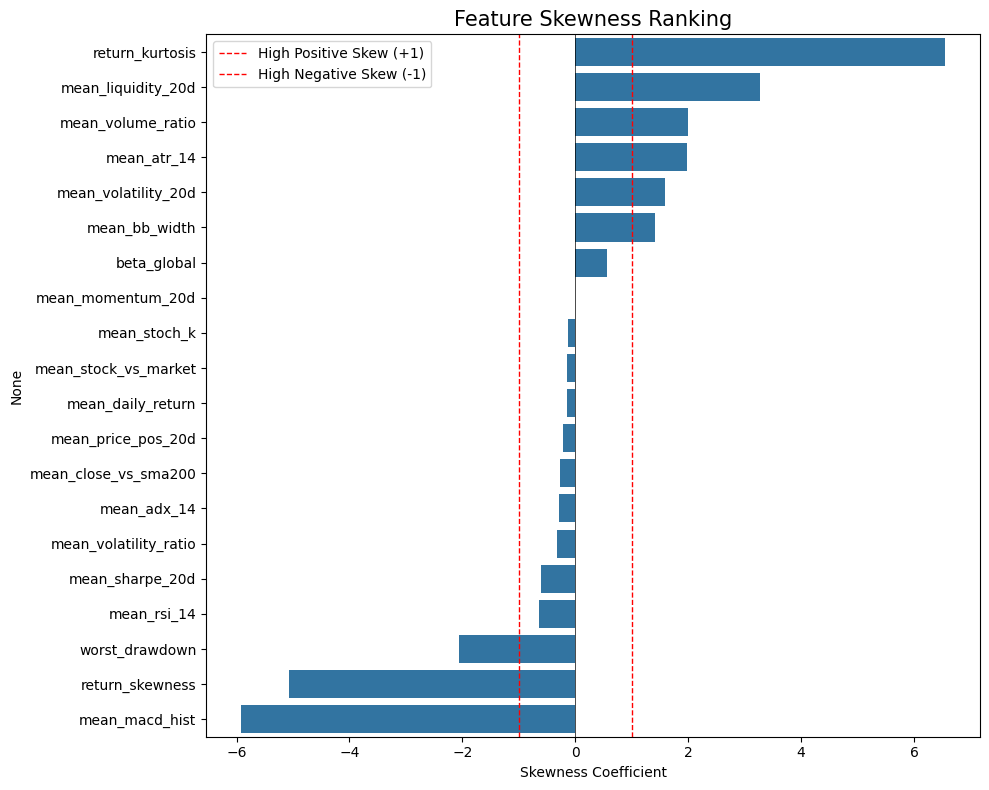

In [279]:
skew_data, normal_data = skewness_analysis(features, skew_threshold)

Applied Yeo-Johnson transformation for 9 values


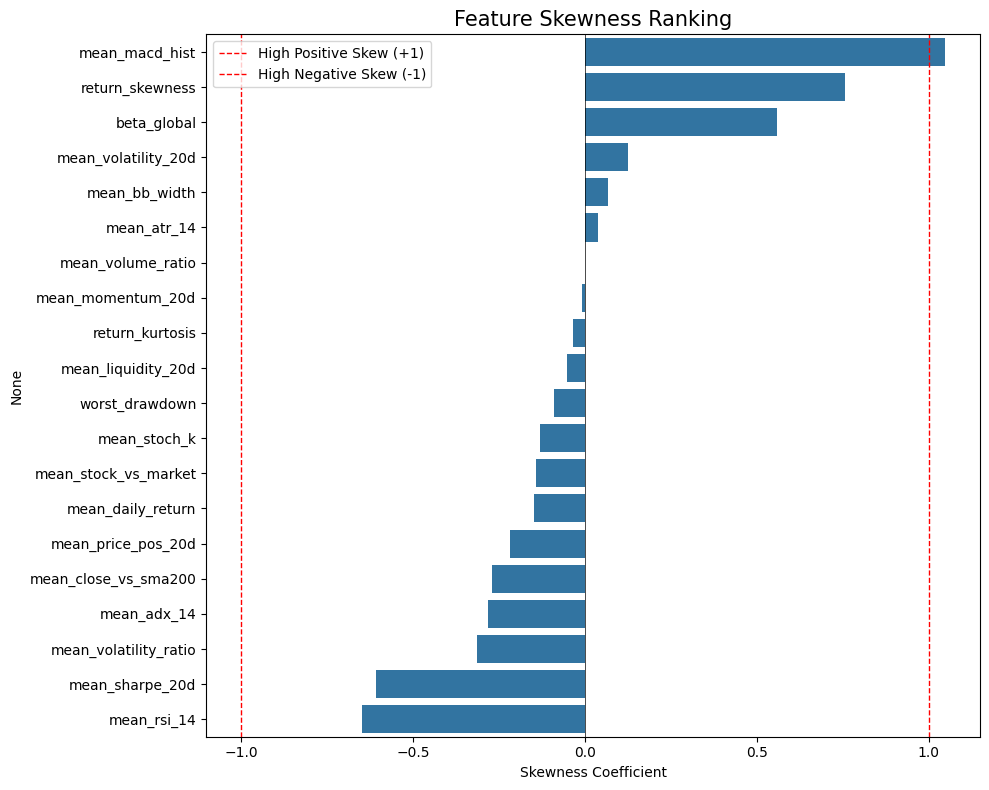

In [281]:
features_skew_transformed = skew_transformation(features, skew_data)
skew_data_transform, normal_skew_transform = skewness_analysis(features_skew_transformed, skew_threshold)

### 2.3.2 Scaling (Standardization)

In [282]:
def data_standardization(data, columns):
    scaler = StandardScaler()
    data_scaled = pd.DataFrame(scaler.fit_transform(data[columns]), columns = columns)
    
    return data_scaled

In [283]:
feature_scaled = data_standardization(features_skew_transformed, numeric_cols)

In [284]:
feature_scaled.head()

,mean_daily_return,mean_momentum_20d,mean_close_vs_sma200,mean_stock_vs_market,beta_global,mean_volatility_20d,mean_sharpe_20d,worst_drawdown,mean_atr_14,mean_volatility_ratio,mean_rsi_14,mean_adx_14,mean_macd_hist,mean_stoch_k,mean_bb_width,mean_liquidity_20d,mean_volume_ratio,mean_price_pos_20d,return_skewness,return_kurtosis
0,-0.0582,-0.1848,-0.1343,-0.0565,0.7291,0.0458,0.3545,-0.4592,0.3584,-1.2705,0.3076,-0.4144,0.2761,0.5451,0.0649,1.5460,-0.0000,0.5787,0.7832,1.0198
1,-0.0690,-0.2983,-0.0426,-0.0673,-1.0345,-0.2248,0.3080,0.7933,0.1661,0.8756,0.2401,1.3296,-0.4536,-0.0213,-0.0022,-0.3059,0.0000,-0.0882,-0.9282,0.6603
2,0.2393,0.2137,0.0473,0.2410,1.0422,0.5914,0.0804,-0.2425,0.4216,0.7957,0.0846,-0.7549,0.6846,0.3193,0.3126,1.3198,0.0000,0.4718,0.1793,-0.2778
3,0.3864,0.4718,0.5300,0.3881,0.9585,0.2165,0.4978,-0.0675,0.6564,-0.5771,0.6655,-1.0116,0.3833,0.9981,0.1429,-0.6485,-0.0000,1.0593,0.3472,0.5388
4,-0.2298,-0.2024,-0.2023,-0.2281,0.5537,0.7746,-0.1787,-1.3621,0.4149,-0.3471,-0.3449,0.6074,-0.3588,-0.7652,0.8879,-0.0186,0.0000,-0.8070,0.0827,0.3816


# 3. Feature Selection (Dimensionality Reduction)

## 3.1 (Optional) Manually remove highly correlated features

In [ ]:
# Remove highly correlated features (keep only one from each pair)
corr_matrix = feature_scaled[numeric_cols].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.92:  # Very high correlation
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))

# Remove one feature from each highly correlated pair
features_to_remove = set()
for feat1, feat2 in high_corr_pairs:
    # Keep the one with more variance (more informative)
    if feature_scaled[feat1].var() < feature_scaled[feat2].var():
        features_to_remove.add(feat1)
    else:
        features_to_remove.add(feat2)

selected_features = [f for f in numeric_cols if f not in features_to_remove]
print(f"Selected {len(selected_features)} features from {len(numeric_cols)}")

Selected 14 features from 20


In [ ]:
# features_cleaned = feature_scaled[selected_features]
# features_cleaned.head()

## 3.2 Apply PCA for principal components

In [285]:
def pca_apply(data, n_components=0.95):
    pca = PCA(n_components=n_components)
    data_pca = pca.fit_transform(data)
    print(f"Original features: {data.shape[1]}")
    print(f"PCA components: {data_pca.shape[1]}")
    print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA Explained Variance (Cumulative)")
    plt.axhline(y=n_components, color='r', linestyle='--', label=f'{n_components * 100} % Variance')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.bar(range(1, min(21, len(pca.explained_variance_ratio_) + 1)),
            pca.explained_variance_ratio_[:20])
    plt.xlabel("Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Top 20 Components Explained Variance")
    
    plt.tight_layout()
    plt.show()
    
    return data_pca, pca

Original features: 20
PCA components: 9
Variance explained: 97.33%


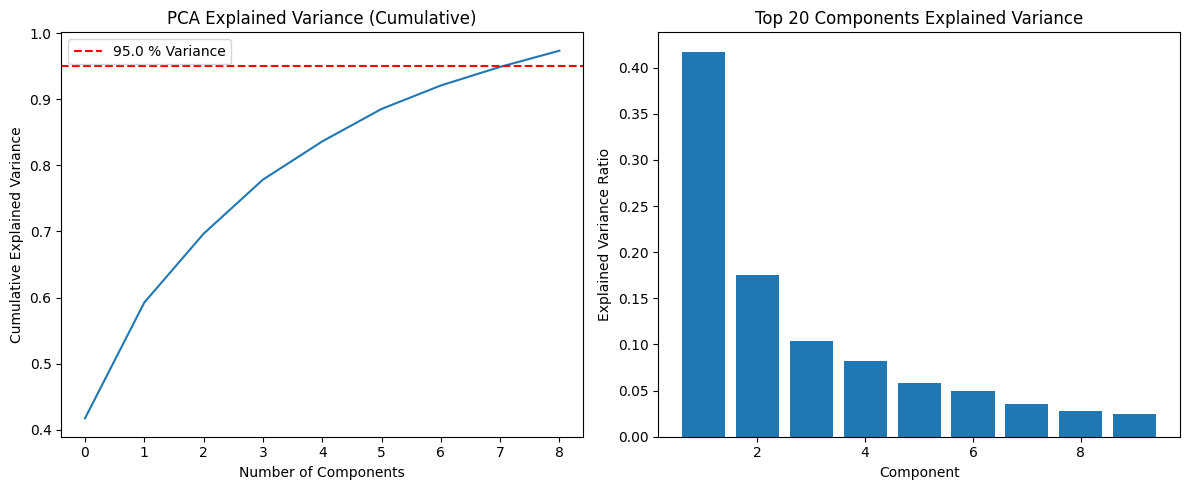

In [286]:
feature_pca, pca = pca_apply(feature_scaled, n_components=0.95)

# 4. Clustering Feasibility with Hopkins Statistic

In [287]:
def hopkins_statistic(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    
    rand_X = sample(range(0, n, 1), m)
    ujd = []
    wjd = []
    
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(np.random.uniform(np.amin(X, axis=0), np.amax(X, axis=0), d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
        
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    
    if isnan(H):
        print(ujd, wjd)
        H = 0
        
    return H

In [288]:
h_stat = hopkins_statistic(feature_pca)

In [289]:
h_stat

np.float64(0.6577101052004886)

This hopkins statistic does not return theoretically perfect result, but it's a good number for real-world practice.
Since ...

# 5. Model training

## Feature-based clustering

In [290]:
def find_optimal_clusters(data, max_k=10, random_state=42):
    k_range = range(2, max_k + 1)
    metrics = {
        'k': [],
        'silhouette': [],
        'davies_bouldin': [],
        'calinski_harabasz': [],
        'inertia': []
    }
    
    print("Testing optimal number of clusters...")
    print(f"{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18} {'Inertia':<10}")
    print("-" * 70)
    
    for k in k_range:
        pam = KMedoids(n_clusters=k, metric='euclidean', random_state=random_state, init='k-medoids++')
        labels = pam.fit_predict(data)
        
        silhouette = silhouette_score(data, labels)
        db_score = davies_bouldin_score(data, labels)
        ch_score = calinski_harabasz_score(data, labels)
        inertia = pam.inertia_
        
        metrics['k'].append(k)
        metrics['silhouette'].append(silhouette)
        metrics['davies_bouldin'].append(db_score)
        metrics['calinski_harabasz'].append(ch_score)
        metrics['inertia'].append(inertia)
        
        print(f"{k:<5} {silhouette:<12.4f} {db_score:<15.4f} {ch_score:<18.4f} {inertia:<10.2f}")
        
    metrics_df = pd.DataFrame(metrics)
    
    # Visualize metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Silhouette Score (higher is better)
    axes[0, 0].plot(metrics_df['k'], metrics_df['silhouette'], marker='o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Number of Clusters (k)')
    axes[0, 0].set_ylabel('Silhouette Score')
    axes[0, 0].set_title('Silhouette Score vs k (Higher is Better)')
    axes[0, 0].grid(True, alpha=0.3)
    # axes[0, 0].axvline(x=metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'], 
    #                    color='r', linestyle='--', alpha=0.5, label='Optimal k')
    axes[0, 0].legend()
    
    # Davies-Bouldin Score (lower is better)
    axes[0, 1].plot(metrics_df['k'], metrics_df['davies_bouldin'], marker='o', linewidth=2, markersize=8, color='orange')
    axes[0, 1].set_xlabel('Number of Clusters (k)')
    axes[0, 1].set_ylabel('Davies-Bouldin Score')
    axes[0, 1].set_title('Davies-Bouldin Score vs k (Lower is Better)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Calinski-Harabasz Score (higher is better)
    axes[1, 0].plot(metrics_df['k'], metrics_df['calinski_harabasz'], marker='o', linewidth=2, markersize=8, color='green')
    axes[1, 0].set_xlabel('Number of Clusters (k)')
    axes[1, 0].set_ylabel('Calinski-Harabasz Score')
    axes[1, 0].set_title('Calinski-Harabasz Score vs k (Higher is Better)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Elbow Method (Inertia)
    axes[1, 1].plot(metrics_df['k'], metrics_df['inertia'], marker='o', linewidth=2, markersize=8, color='purple')
    axes[1, 1].set_xlabel('Number of Clusters (k)')
    axes[1, 1].set_ylabel('Inertia (Within-cluster Sum of Squares)')
    axes[1, 1].set_title('Elbow Method (Inertia)')
    axes[1, 1].grid(True, alpha=0.3)
    for ax in axes.flat:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()
    
    return metrics_df

Testing optimal number of clusters...
k     Silhouette   Davies-Bouldin  Calinski-Harabasz  Inertia   
----------------------------------------------------------------------
2     0.2360       1.4803          18.5009            176.93    
3     0.1901       1.1696          9.9926             171.28    
4     0.1571       1.3278          11.3067            156.52    
5     0.1535       1.5441          10.0292            151.16    
6     0.1218       1.5444          9.8491             139.78    
7     0.1380       1.2891          10.2883            130.79    
8     0.1143       1.5891          8.7110             123.79    
9     0.1247       1.2758          9.2966             116.71    
10    0.0954       1.3160          8.0327             114.68    
11    0.1038       1.1925          8.2693             108.87    
12    0.1028       1.1283          8.0705             102.89    
13    0.0978       0.9927          8.6046             96.11     
14    0.1017       0.9358          8.8914     

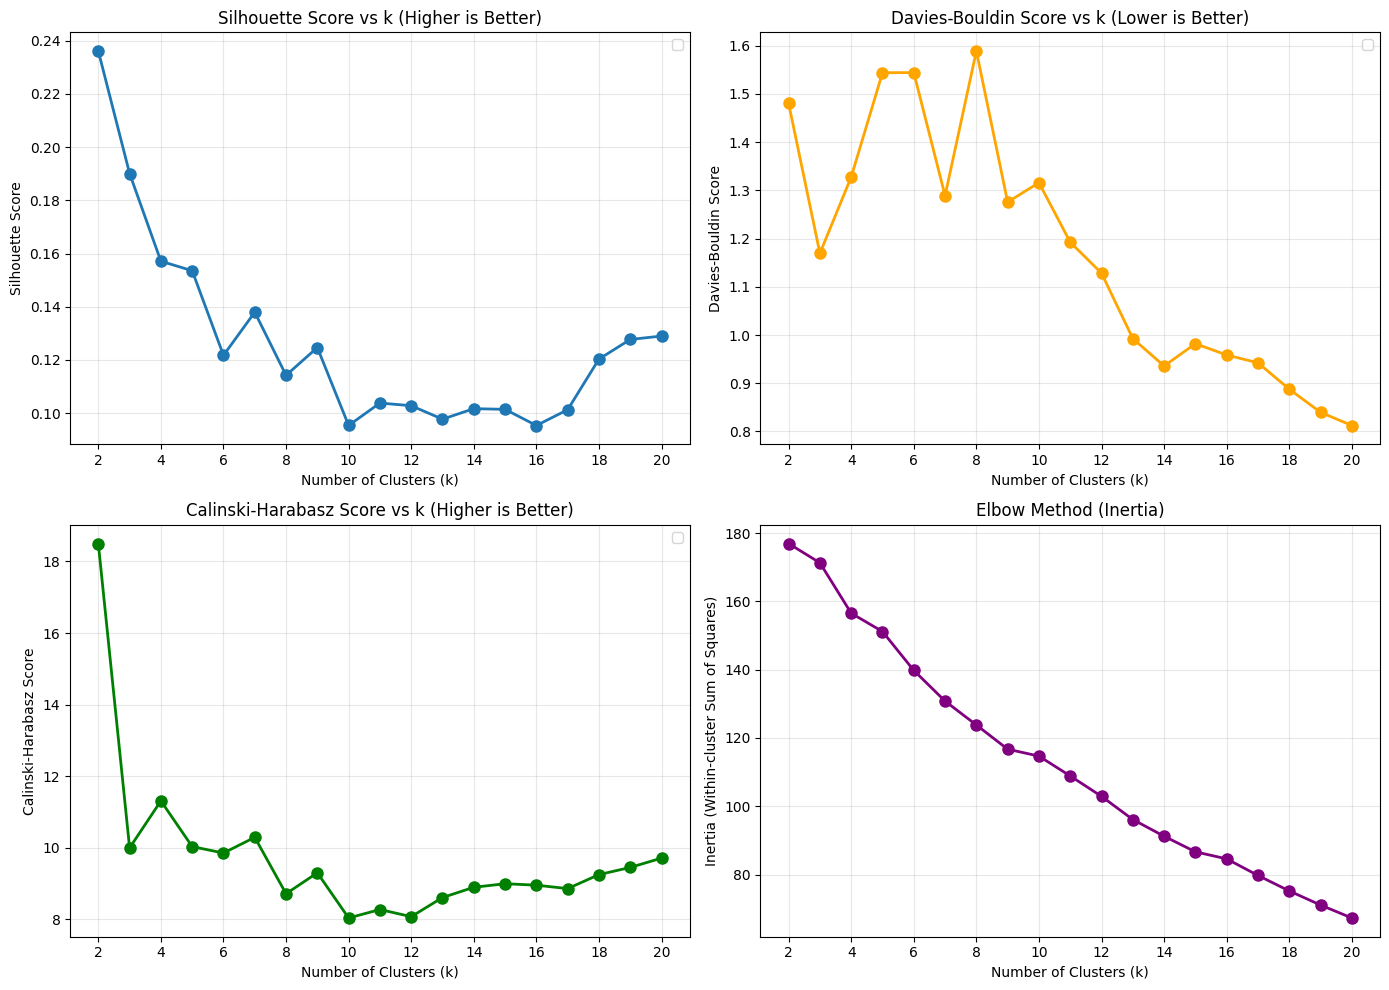

In [291]:
optimal_metrics = find_optimal_clusters(feature_pca, max_k=20)

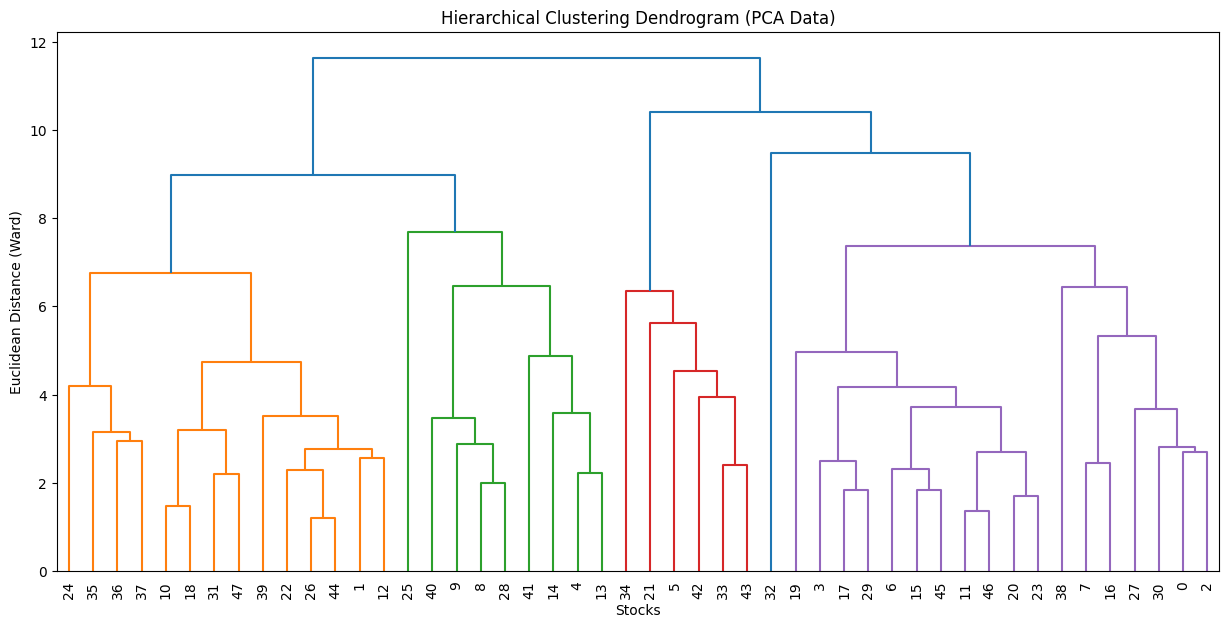

In [302]:
Z = sch.linkage(feature_pca, method='complete')

plt.figure(figsize=(15, 7))
plt.title("Hierarchical Clustering Dendrogram (PCA Data)")
plt.xlabel("Stocks")
plt.ylabel("Euclidean Distance (Ward)")

sch.dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.show()

In [293]:
# Create labels for k=5
labels_5 = sch.fcluster(Z, t=5, criterion='maxclust')

if isinstance(feature_pca, np.ndarray):
    feature_pca = pd.DataFrame(feature_pca, columns=[f'PC{i+1}' for i in range(feature_pca.shape[1])])
    
# Add to dataframe
df_pca_copy = feature_pca.copy()
df_pca_copy['Cluster_HC'] = labels_5
df_pca_copy['Ticker'] = global_data['ticker'].values # Assuming global_data is aligned

# Count stocks per cluster
print(df_pca_copy['Cluster_HC'].value_counts())

# See who is in the smallest cluster (Likely Stock 32)
smallest_cluster = df_pca_copy['Cluster_HC'].value_counts().idxmin()
print(f"\nStocks in the smallest cluster ({smallest_cluster}):")
print(df_pca_copy[df_pca_copy['Cluster_HC'] == smallest_cluster]['Ticker'].tolist())

Cluster_HC
4    18
1    14
2     9
3     6
5     1
Name: count, dtype: int64

Stocks in the smallest cluster (5):
['NFLX']


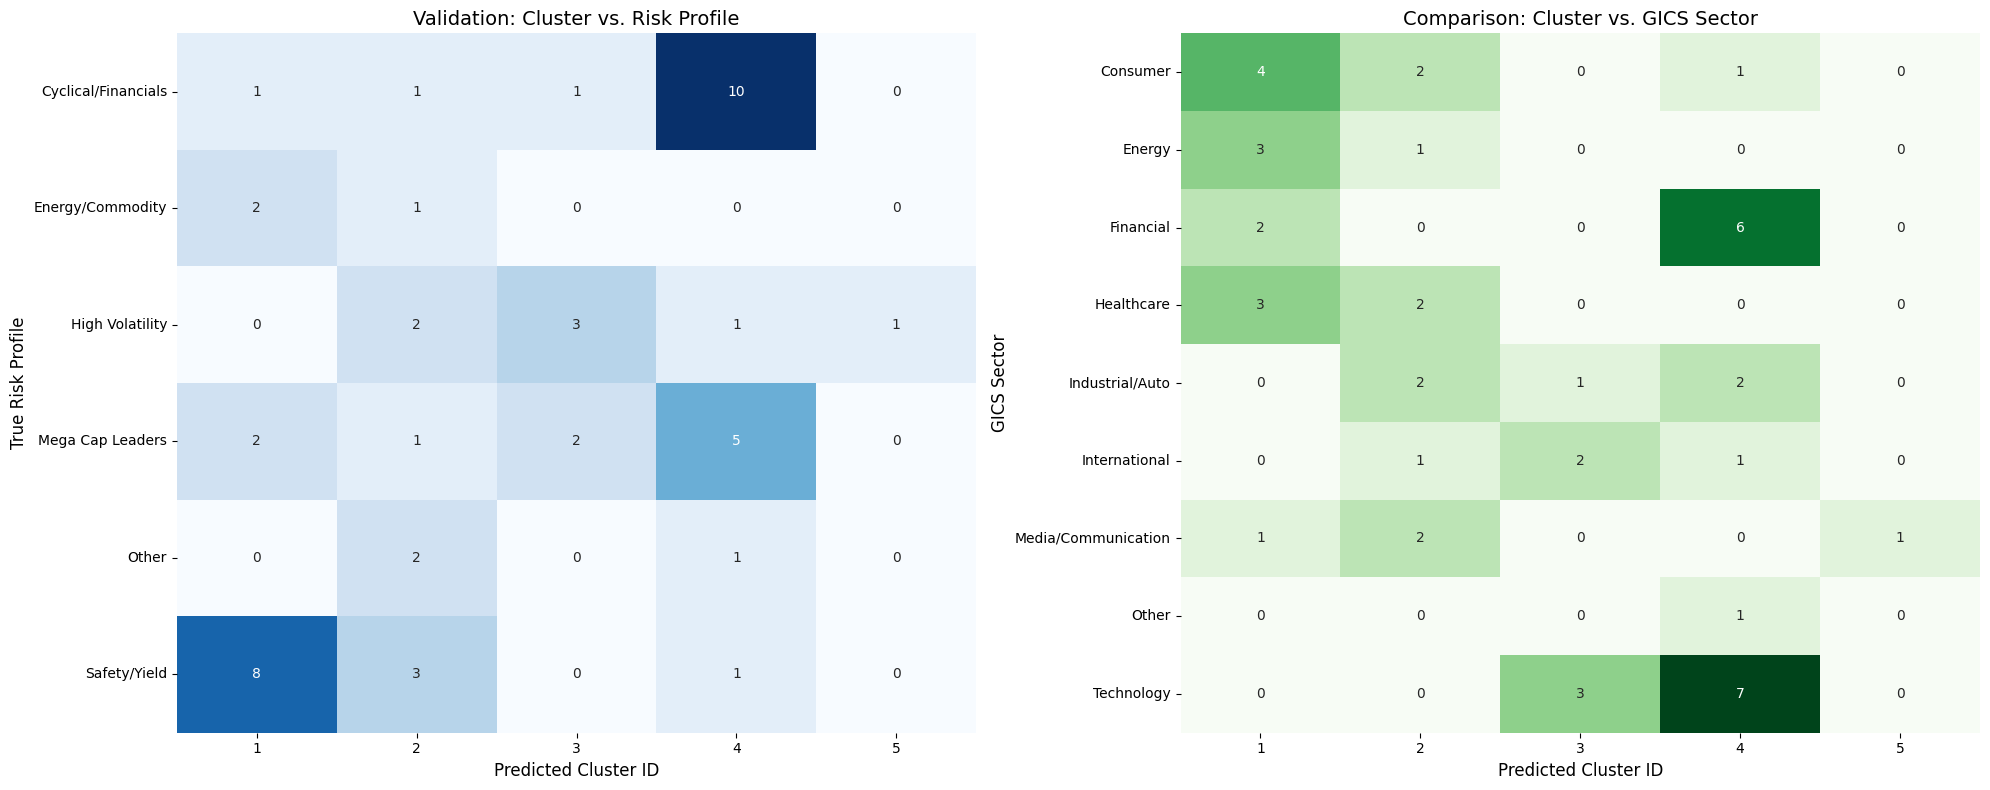


🕵️‍♂️ The 'Loner' in Cluster 5 is:
   Ticker     Risk_Profile               Sector
32   NFLX  High Volatility  Media/Communication


In [244]:
# 1. Map the Tickers to Profiles
# We use .map() and fillna('Other') in case a stock isn't in our dictionary
df_pca_copy['Risk_Profile'] = df_pca_copy['Ticker'].map(SYMBOL_TO_RISK_PROFILE).fillna('Other')
df_pca_copy['Sector'] = df_pca_copy['Ticker'].map(SYMBOL_TO_SECTOR).fillna('Other')

# 2. Create Crosstabs (Confusion Matrices)
risk_crosstab = pd.crosstab(df_pca_copy['Risk_Profile'], df_pca_copy['Cluster_HC'])
sector_crosstab = pd.crosstab(df_pca_copy['Sector'], df_pca_copy['Cluster_HC'])

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot A: Risk Profile Validation (The Main Event)
sns.heatmap(risk_crosstab, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Validation: Cluster vs. Risk Profile', fontsize=14)
axes[0].set_ylabel('True Risk Profile', fontsize=12)
axes[0].set_xlabel('Predicted Cluster ID', fontsize=12)

# Plot B: Sector Validation (The Sector Check)
sns.heatmap(sector_crosstab, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('Comparison: Cluster vs. GICS Sector', fontsize=14)
axes[1].set_ylabel('GICS Sector', fontsize=12)
axes[1].set_xlabel('Predicted Cluster ID', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Investigate the "Loner" (Cluster with 1 stock)
loner_cluster_id = df_pca_copy['Cluster_HC'].value_counts().idxmin() # Finds the ID with count 1
loner_stock = df_pca_copy[df_pca_copy['Cluster_HC'] == loner_cluster_id]

print(f"\n🕵️‍♂️ The 'Loner' in Cluster {loner_cluster_id} is:")
print(loner_stock[['Ticker', 'Risk_Profile', 'Sector']])

In [298]:
def apply_kmeans_clustering(data, n_clusters=5, random_state=42):
    
    kmeans_model = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=10,
        random_state=random_state,
        max_iter=300
    )
    
    labels = kmeans_model.fit_predict(data)
    
    silhouette = silhouette_score(data, labels)
    db_score = davies_bouldin_score(data, labels)
    ch_score = calinski_harabasz_score(data, labels)
    
    print(f"Silhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)")
    print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {ch_score:.4f} (higher is better)")

    closest_indices, _ = pairwise_distances_argmin_min(
        kmeans_model.cluster_centers_, data
    )
    
    for i, idx in enumerate(closest_indices):
        print(f"Cluster {i} Representative: {tickers[idx]}")
    
    return {
        'model': kmeans_model,
        'labels': labels,
        'medoids': closest_indices,
        'silhouette': silhouette,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score,
        'n_clusters': n_clusters
    }

In [295]:
def apply_pam_clustering(data, metric='euclidean', n_clusters=5, random_state=42):
    pam_model = KMedoids(
        n_clusters=n_clusters,
        metric=metric,
        method='pam',
        init='k-medoids++',
        random_state=random_state,
        max_iter=300
    )
    
    labels = pam_model.fit_predict(data)
    
    # Calculate quality metrics
    silhouette = silhouette_score(data, labels)
    db_score = davies_bouldin_score(data, labels)
    ch_score = calinski_harabasz_score(data, labels)
    
    print(f"Silhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)")
    print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {ch_score:.4f} (higher is better)")
    
    # Get medoids (representative stocks for each cluster)
    medoids = pam_model.medoid_indices_
    for medoid in medoids:
        print(f"Medoids (representative stocks): {tickers[medoid]}")
    
    return {
        'model': pam_model,
        'labels': labels,
        'medoids': medoids,
        'silhouette': silhouette,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score,
        'n_clusters': n_clusters
    }

In [296]:
def cluster_loop(data, methods = ['k-means', 'pam'], metrics=['euclidean', 'manhattan', 'cosine'], n_clusters=range(2, 10)):
    cluster_loop = {}
    if isinstance(n_clusters, int):
        n_clusters = [n_clusters]
    for method in methods:
        if method == 'k-means':
            for n_cluster in n_clusters:
                for metric in metrics:
                    column = f"kmeans_{metric}_{n_cluster}"
                    cluster_loop[column] = apply_kmeans_clustering(data, n_clusters=n_cluster)
        if method == 'pam':    
            for n_cluster in n_clusters:
                for metric in metrics:
                    column = f"pam_{metric}_{n_cluster}"
                    cluster_loop[column] = apply_pam_clustering(data, metric=metric, n_clusters=n_cluster)
    return cluster_loop

In [303]:
clusters = cluster_loop(feature_pca, n_clusters=3)

Silhouette Score: 0.2057 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.5516 (lower is better)
Calinski-Harabasz Score: 16.4859 (higher is better)
Cluster 0 Representative: TSM
Cluster 1 Representative: NEE
Cluster 2 Representative: WMT
Silhouette Score: 0.2057 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.5516 (lower is better)
Calinski-Harabasz Score: 16.4859 (higher is better)
Cluster 0 Representative: TSM
Cluster 1 Representative: NEE
Cluster 2 Representative: WMT
Silhouette Score: 0.2057 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.5516 (lower is better)
Calinski-Harabasz Score: 16.4859 (higher is better)
Cluster 0 Representative: TSM
Cluster 1 Representative: NEE
Cluster 2 Representative: WMT
Silhouette Score: 0.1707 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.6313 (lower is better)
Calinski-Harabasz Score: 14.1861 (higher is better)
Medoids (representative stocks): CVX
Medoids (representative stocks): MS
Medoids (representati

In [ ]:
def visualize_clusters_pca(data_pca_9d, labels, tickers, n_clusters):
    from mpl_toolkits.mplot3d import Axes3D
    
    # Project to 2D for visualization
    pca_2d = PCA(n_components=2)
    data_2d = pca_2d.fit_transform(data_pca_9d)
    
    # Project to 3D for visualization
    pca_3d = PCA(n_components=3)
    data_3d = pca_3d.fit_transform(data_pca_9d)
    
    # Create color palette
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    # 2D Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 2D scatter plot
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        axes[0].scatter(
            data_2d[cluster_mask, 0],
            data_2d[cluster_mask, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id + 1}',
            alpha=0.7,
            s=100,
            edgecolors='black',
            linewidth=1.5
        )
    
    axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    axes[0].set_title('PAM Clusters - 2D PCA Projection', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Add ticker labels (optional - can be cluttered with 48 stocks)
    # Uncomment if you want to see ticker names
    for i, ticker in enumerate(tickers):
        axes[0].annotate(ticker, (data_2d[i, 0], data_2d[i, 1]), fontsize=6)
    
    # 3D Visualization
    ax_3d = fig.add_subplot(122, projection='3d')
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        ax_3d.scatter(
            data_3d[cluster_mask, 0],
            data_3d[cluster_mask, 1],
            data_3d[cluster_mask, 2],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id + 1}',
            alpha=0.7,
            s=100,
            edgecolors='black',
            linewidth=1.5
        )
    
    ax_3d.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%} variance)', fontsize=10)
    ax_3d.set_title('PAM Clusters - 3D PCA Projection', fontsize=14, fontweight='bold')
    ax_3d.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    # plt.savefig(f'{output_dir}/pam_clusters_pca_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pca_2d, pca_3d, data_2d, data_3d

In [305]:
def visualize_all_clusters(clusters, data_pca, tickers):
    print(f"Visualizing {len(clusters)} clustering results...")
    print("="*80)
    
    for method_name, cluster_result in clusters.items():
        print(f"\nVisualizing: {method_name}")
        print("-" * 80)
        
        # Extract clustering info
        labels = cluster_result['labels']
        n_clusters = cluster_result.get('n_clusters', len(np.unique(labels)))
        
        # Print metrics
        print(f"Silhouette Score: {cluster_result['silhouette']:.4f}")
        print(f"Davies-Bouldin Score: {cluster_result['davies_bouldin']:.4f}")
        print(f"Calinski-Harabasz Score: {cluster_result['calinski_harabasz']:.4f}")
        
        # Visualize
        visualize_clusters_pca(
            data_pca_9d=data_pca,
            labels=labels,
            tickers=tickers,
            n_clusters=n_clusters
        )
        
        # Add a small delay to see each plot (optional)
        # plt.pause(0.5)
    
    print("\n" + "="*80)
    print("All visualizations complete!")
    print("="*80)

# Usage:
# visualize_all_clusters(clusters, feature_pca, tickers)

Visualizing 6 clustering results...

Visualizing: kmeans_euclidean_3
--------------------------------------------------------------------------------
Silhouette Score: 0.2057
Davies-Bouldin Score: 1.5516
Calinski-Harabasz Score: 16.4859


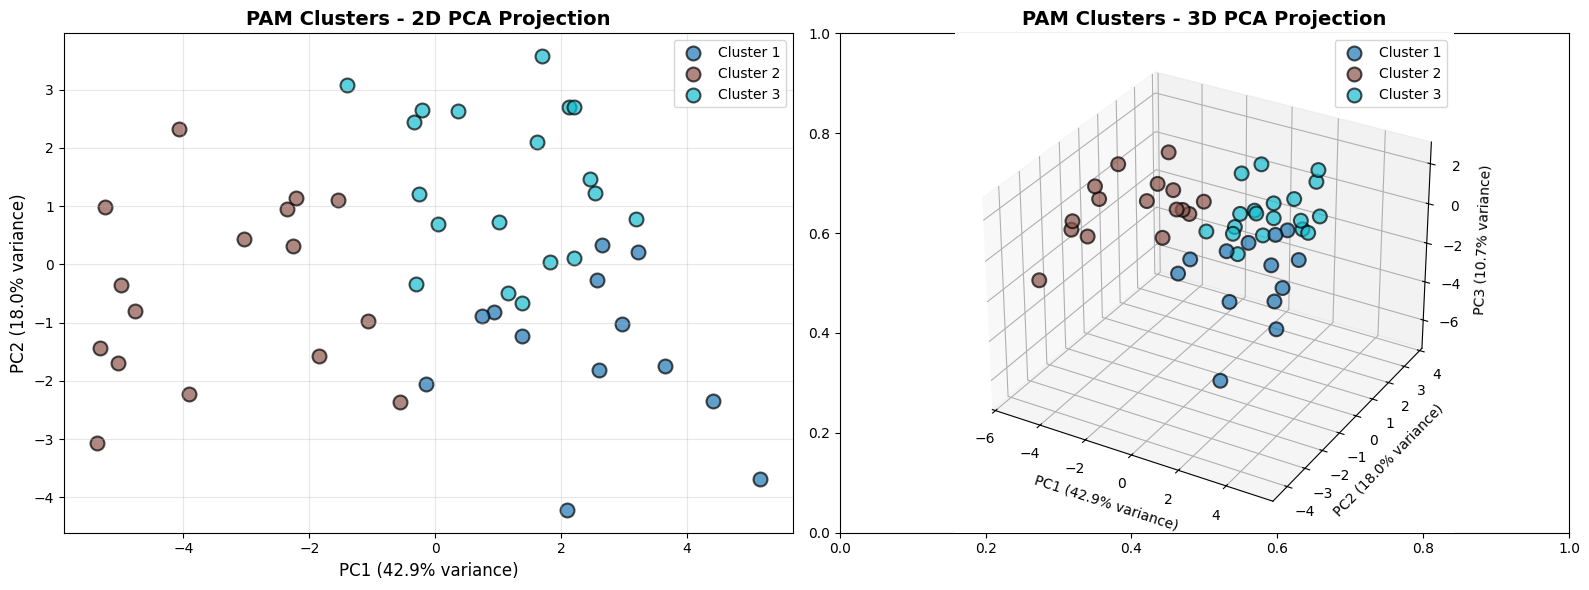


Visualizing: kmeans_manhattan_3
--------------------------------------------------------------------------------
Silhouette Score: 0.2057
Davies-Bouldin Score: 1.5516
Calinski-Harabasz Score: 16.4859


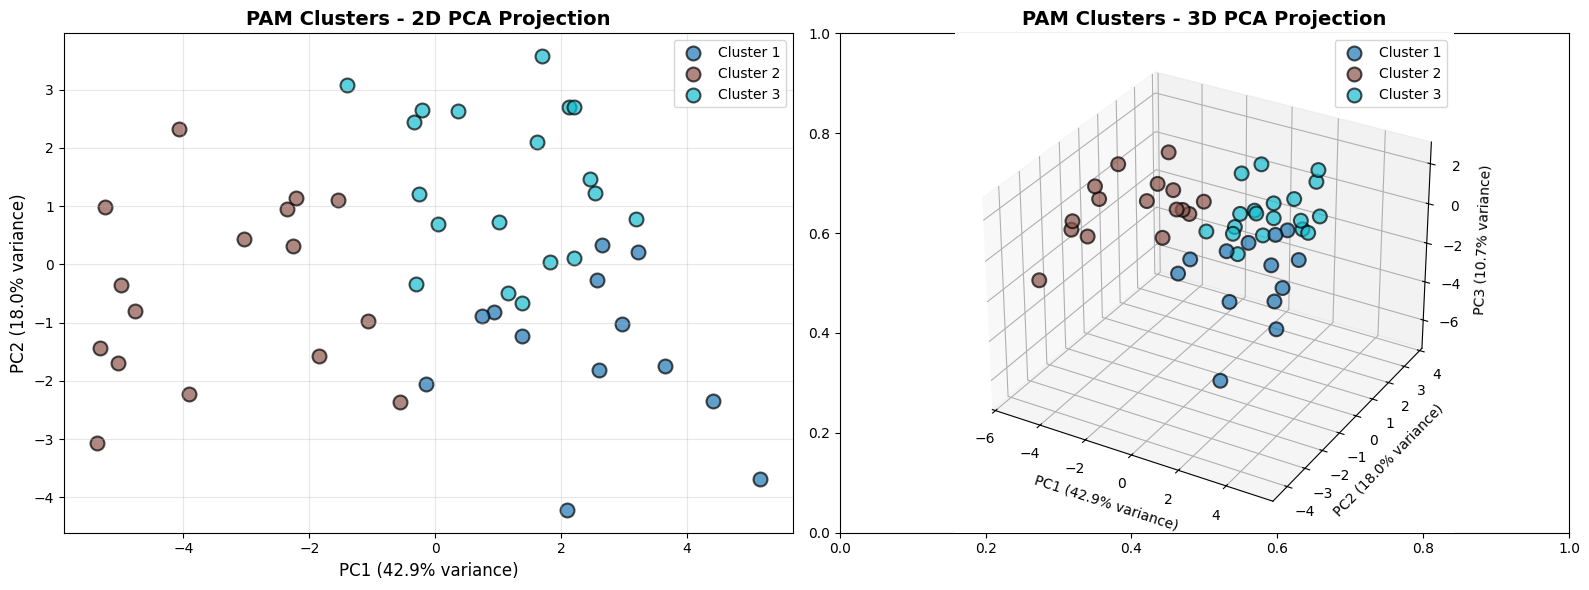


Visualizing: kmeans_cosine_3
--------------------------------------------------------------------------------
Silhouette Score: 0.2057
Davies-Bouldin Score: 1.5516
Calinski-Harabasz Score: 16.4859


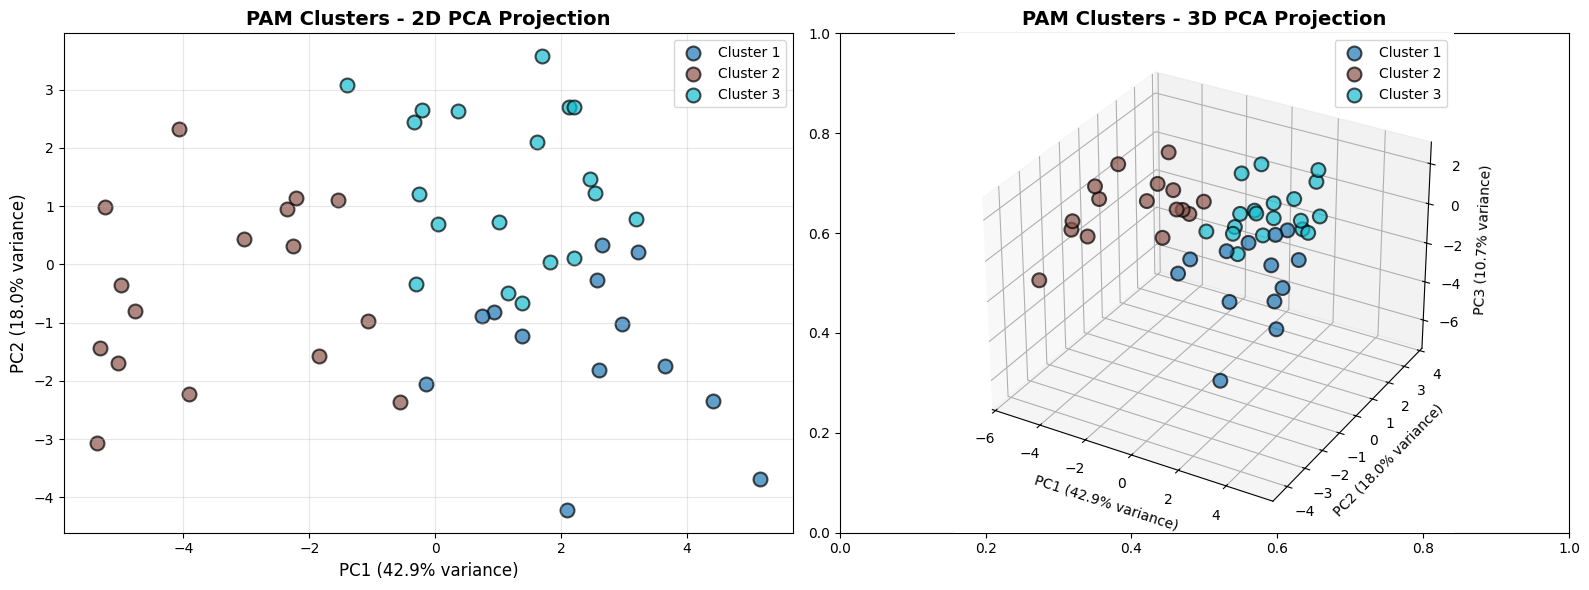


Visualizing: pam_euclidean_3
--------------------------------------------------------------------------------
Silhouette Score: 0.1707
Davies-Bouldin Score: 1.6313
Calinski-Harabasz Score: 14.1861


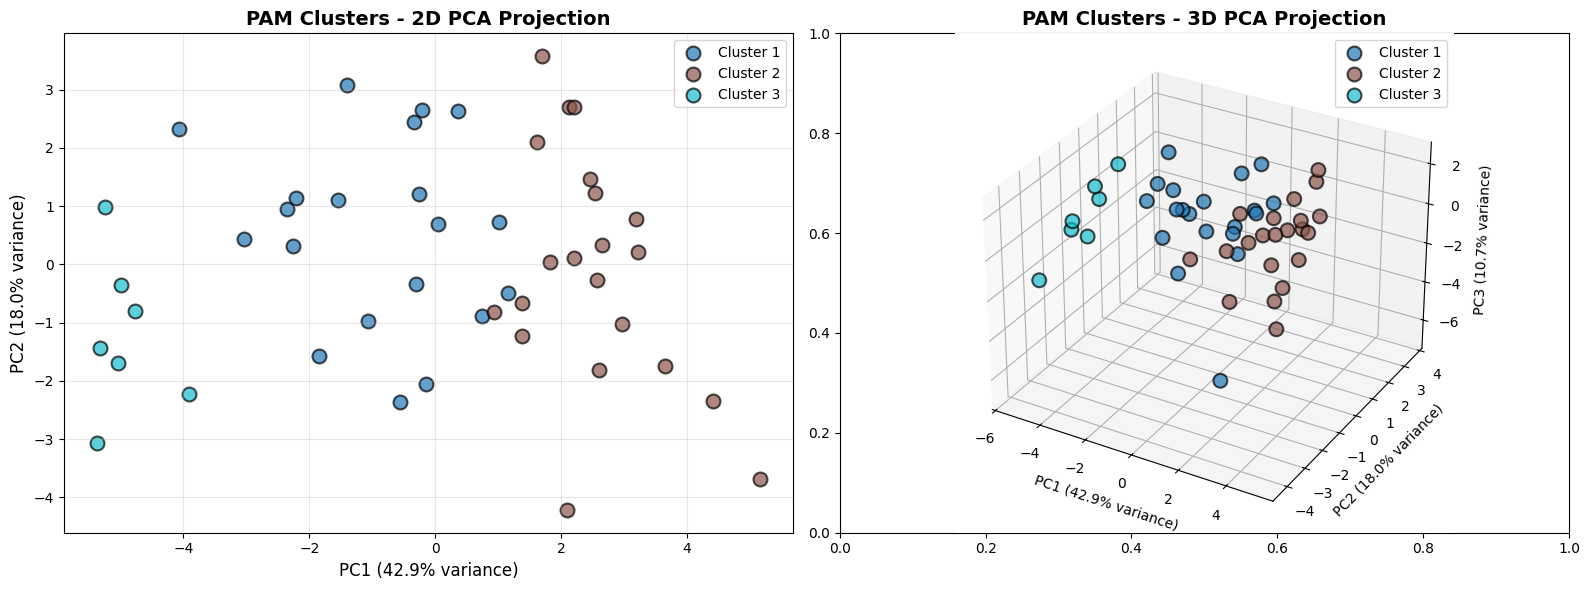


Visualizing: pam_manhattan_3
--------------------------------------------------------------------------------
Silhouette Score: 0.1537
Davies-Bouldin Score: 1.6803
Calinski-Harabasz Score: 14.3013


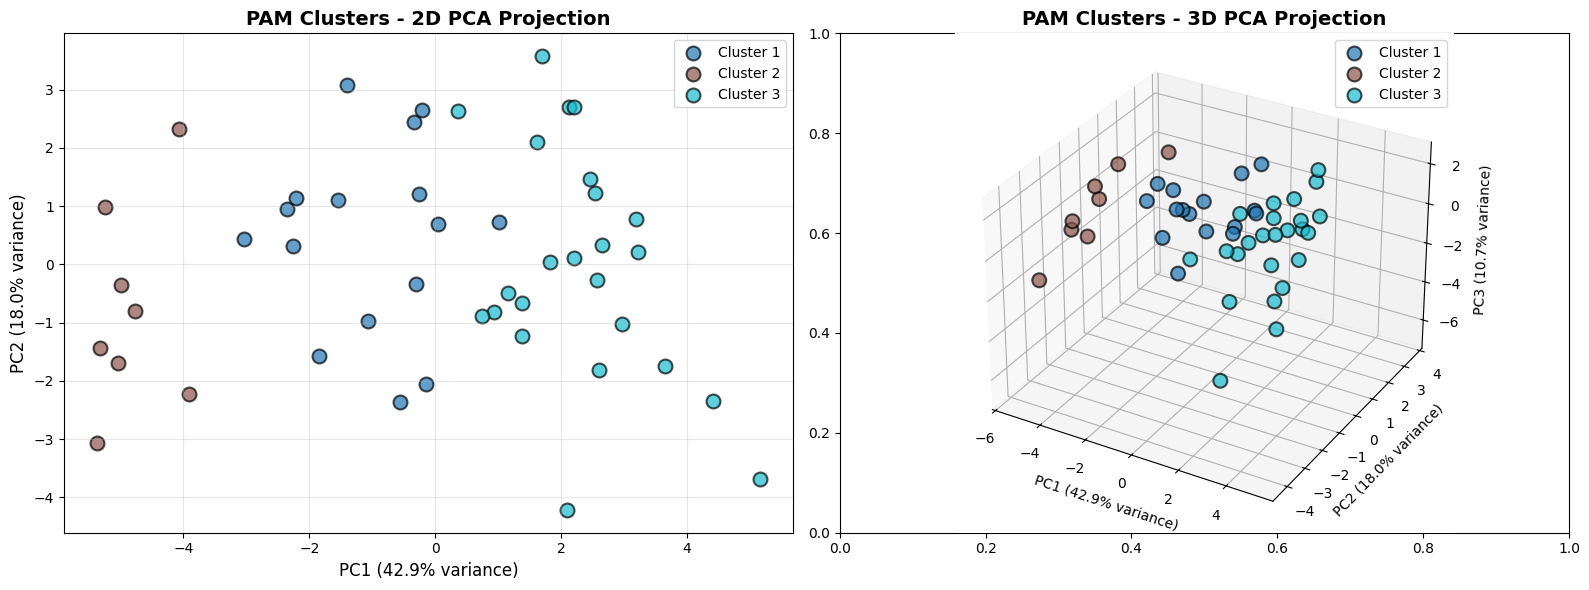


Visualizing: pam_cosine_3
--------------------------------------------------------------------------------
Silhouette Score: 0.1741
Davies-Bouldin Score: 1.4276
Calinski-Harabasz Score: 14.5730


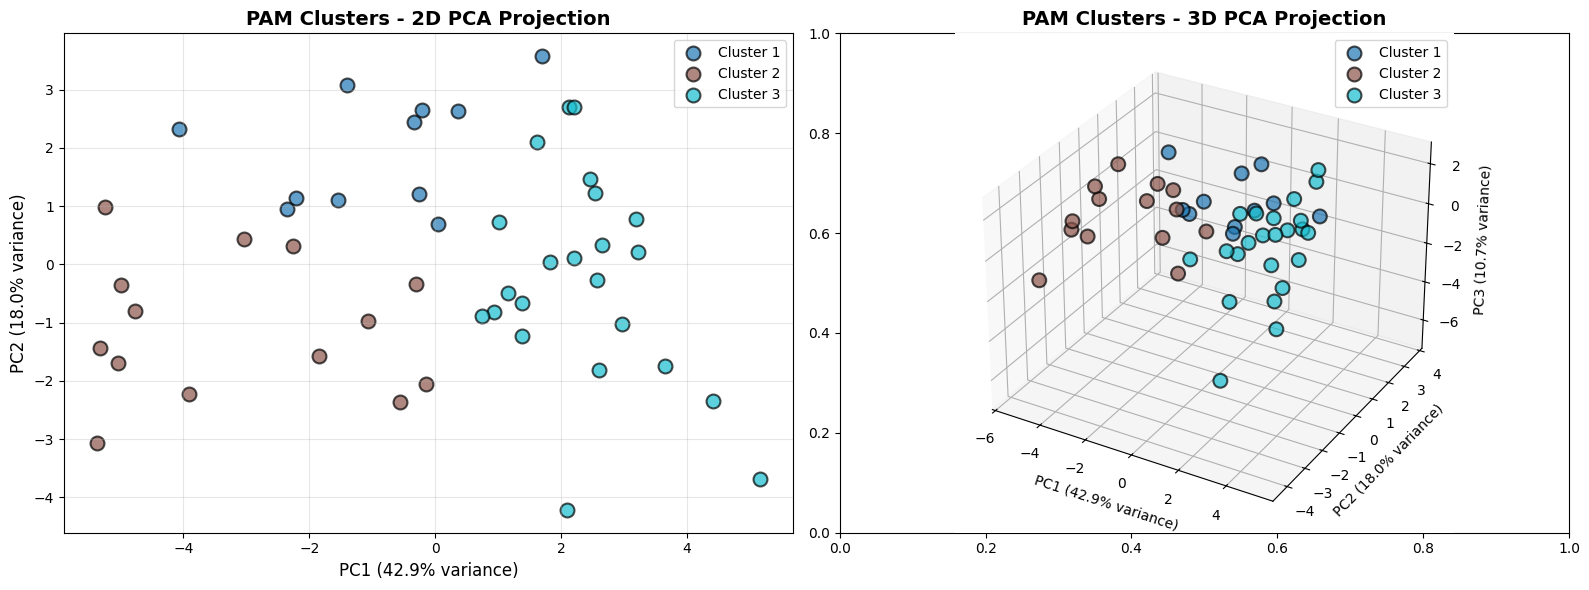


All visualizations complete!


In [306]:
visualize_all_clusters(clusters, feature_pca, tickers)

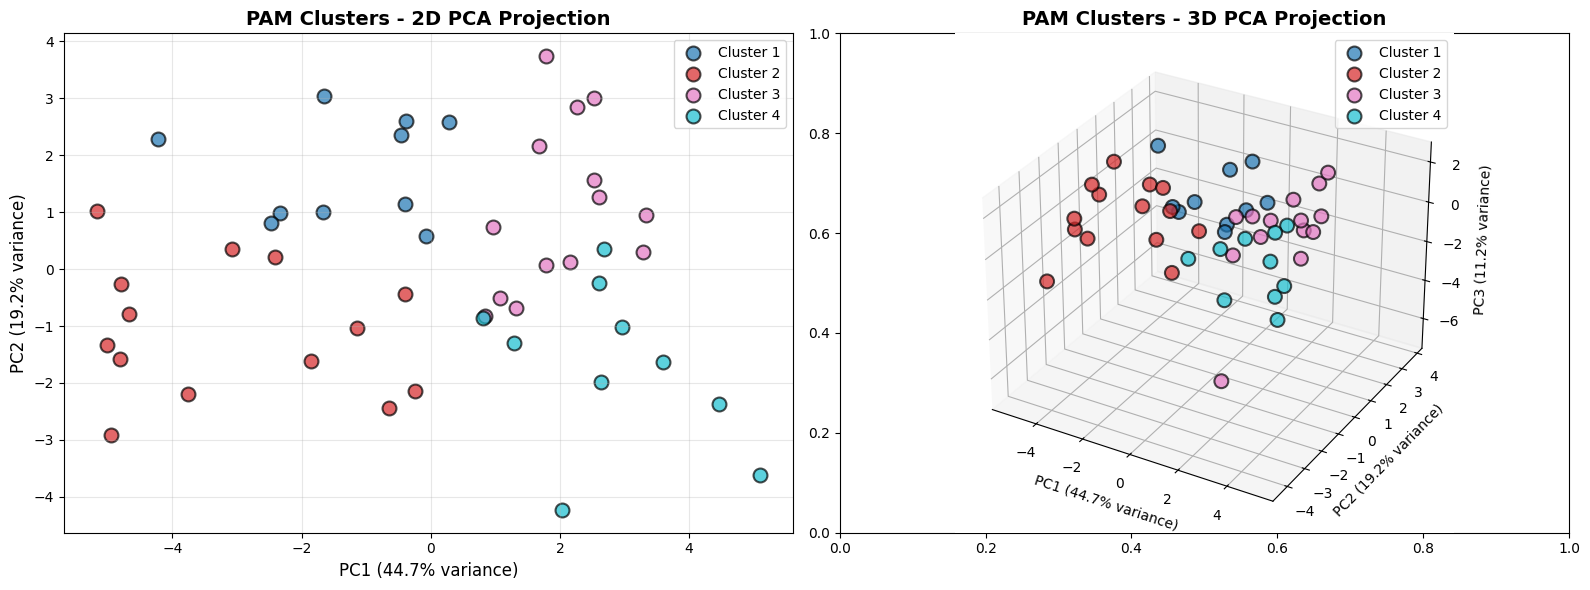

In [ ]:
pca_2d, pca_3d, data_2d, data_3d = visualize_clusters_pca(
        feature_pca, 
        pam_cosine['labels'], 
        tickers, 
        pam_cosine['n_clusters']
    )

In [78]:
global_data['cluster'] = pam_cosine['labels']

In [33]:
# Calculate the median values for each cluster
profile = global_data.groupby('cluster')[['beta_global', 'mean_daily_return', 'mean_volatility_20d', 'mean_rsi_14', 'mean_liquidity_20d']].median()

print(profile)

         beta_global  mean_daily_return  mean_volatility_20d  mean_rsi_14  \
cluster                                                                     
0             0.9830             0.0014               0.0170      56.4671   
1             0.5229            -0.0005               0.0162      46.3480   
2             0.9835             0.0006               0.0212      52.0287   
3             0.4439             0.0003               0.0134      51.5408   
4             1.4077             0.0019               0.0273      54.6982   

         mean_liquidity_20d  
cluster                      
0           1232643619.3396  
1            960758349.5129  
2           2298708014.6074  
3           1301978982.5412  
4           7507121087.1489  


In [79]:
import plotly.express as px

# Select key features for visualization
features_to_plot = ['beta_global', 'mean_volatility_20d', 'mean_rsi_14', 'mean_liquidity_20d']
df_plot = global_data.copy()
df_plot['cluster'] = df_plot['cluster'].astype(int)

fig = px.parallel_coordinates(df_plot, color='cluster',
                              dimensions=features_to_plot,
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              )
fig.show()

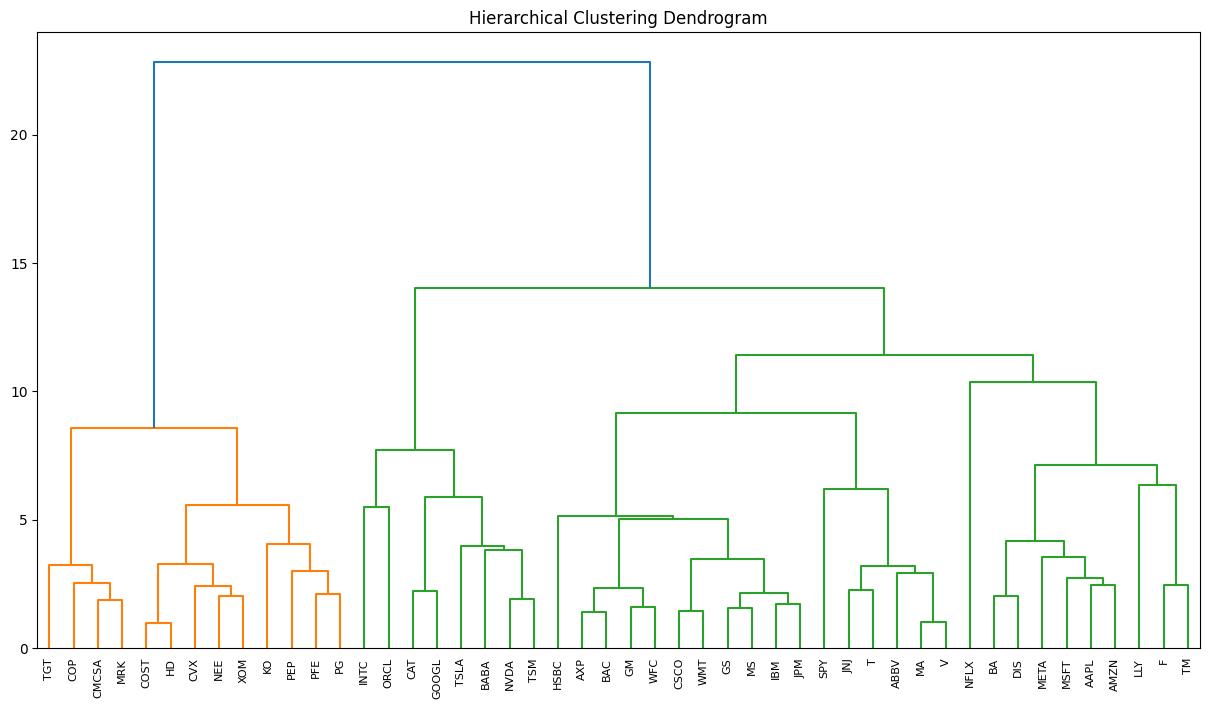

k=3: 3 clusters
  Cluster sizes: [ 0 13  8 27]
k=4: 4 clusters
  Cluster sizes: [ 0 13  8 17 10]
k=5: 5 clusters
  Cluster sizes: [ 0 13  8 17  9  1]
k=6: 6 clusters
  Cluster sizes: [ 0 13  8 11  6  9  1]
k=7: 7 clusters
  Cluster sizes: [ 0  4  9  8 11  6  9  1]


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Create distance matrix
distances = pdist(global_pca, metric='euclidean')
linkage_matrix = linkage(distances, method='ward')

# Plot dendrogram to see natural groupings
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, labels=tickers.values, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

# Try different cut heights to see natural clusters
for n_clusters in [3, 4, 5, 6, 7]:
    labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    print(f"k={n_clusters}: {len(np.unique(labels))} clusters")
    print(f"  Cluster sizes: {np.bincount(labels)}")

In [70]:
global_data.groupby('cluster')['ticker']

In [243]:
SYMBOL_TO_SECTOR = {
    # Technology
    "AAPL": "Technology",
    "MSFT": "Technology",
    "GOOGL": "Technology",
    "AMZN": "Technology",
    "META": "Technology",
    "NVDA": "Technology",
    "INTC": "Technology",
    "CSCO": "Technology",
    "ORCL": "Technology",
    "IBM": "Technology",
    
    # Financial
    "JPM": "Financial",
    "BAC": "Financial",
    "WFC": "Financial",
    "GS": "Financial",
    "MS": "Financial",
    "V": "Financial",
    "MA": "Financial",
    "AXP": "Financial",
    
    # Healthcare
    "JNJ": "Healthcare",
    "PFE": "Healthcare",
    "MRK": "Healthcare",
    "ABBV": "Healthcare",
    "LLY": "Healthcare",
    
    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",
    "NEE": "Energy",
    
    # Consumer
    "WMT": "Consumer",
    "COST": "Consumer",
    "TGT": "Consumer",
    "HD": "Consumer",
    "PG": "Consumer",
    "KO": "Consumer",
    "PEP": "Consumer",
    
    # Industrial/Auto
    "TSLA": "Industrial/Auto",
    "F": "Industrial/Auto",
    "GM": "Industrial/Auto",
    "CAT": "Industrial/Auto",
    "BA": "Industrial/Auto",
    
    # Media/Communication
    "CMCSA": "Media/Communication",
    "DIS": "Media/Communication",
    "NFLX": "Media/Communication",
    "T": "Media/Communication",
    
    # International
    "BABA": "International",
    "TM": "International",
    "TSM": "International",
    "HSBC": "International",
}

SYMBOL_TO_RISK_PROFILE = {
    # --- GROUP 1: MEGA CAP LEADERS (AI/Tech Momentum) ---
    # These detached from the market and rallied hard.
    # Expect them in your "High Liquidity" or "Momentum" cluster.
    "NVDA": "Mega Cap Leaders",
    "META": "Mega Cap Leaders",
    "MSFT": "Mega Cap Leaders",
    "GOOGL": "Mega Cap Leaders",
    "AMZN": "Mega Cap Leaders",
    "TSM": "Mega Cap Leaders", 
    "AAPL": "Mega Cap Leaders", 
    "LLY": "Mega Cap Leaders", # Pharma, but traded like Tech due to GLP-1
    "V": "Mega Cap Leaders",   # Often trades with Tech
    "MA": "Mega Cap Leaders",

    # --- GROUP 2: SAFETY / YIELD (Defensive) ---
    # Low Volatility, Dividend payers. Hurt by high rates but stable.
    # Expect them in your "Low Vol" Cluster.
    "KO": "Safety/Yield",
    "PEP": "Safety/Yield",
    "PG": "Safety/Yield",
    "JNJ": "Safety/Yield",
    "MRK": "Safety/Yield",
    "PFE": "Safety/Yield",
    "ABBV": "Safety/Yield",
    "WMT": "Safety/Yield",
    "COST": "Safety/Yield",
    "T": "Safety/Yield",
    "CMCSA": "Safety/Yield",
    "NEE": "Safety/Yield", # Utility

    # --- GROUP 3: CYCLICAL / FINANCIALS (Economic Sensitivity) ---
    # Banks and Industrials. They move when interest rate expectations change.
    "JPM": "Cyclical/Financials",
    "BAC": "Cyclical/Financials",
    "WFC": "Cyclical/Financials",
    "GS": "Cyclical/Financials",
    "MS": "Cyclical/Financials",
    "AXP": "Cyclical/Financials",
    "HSBC": "Cyclical/Financials",
    "CAT": "Cyclical/Financials",
    "HD": "Cyclical/Financials", # Consumer Cyclical
    "DIS": "Cyclical/Financials",
    "CSCO": "Cyclical/Financials", # Old Tech trades like Cyclical now
    "IBM": "Cyclical/Financials",
    "ORCL": "Cyclical/Financials",

    # --- GROUP 4: ENERGY (Commodity Driven) ---
    # Uncorrelated. Often forms its own small cluster or joins Value.
    "XOM": "Energy/Commodity",
    "CVX": "Energy/Commodity",
    "COP": "Energy/Commodity",

    # --- GROUP 5: HIGH VOLATILITY / DISTRESSED ---
    # Stocks with massive idiosyncratic moves or "Broken" charts.
    "TSLA": "High Volatility", # Traded very differently from MSFT/NVDA recently
    "NFLX": "High Volatility",
    "BA": "High Volatility",   # Boeing 737 crisis
    "INTC": "High Volatility", # Foundry collapse
    "BABA": "High Volatility", # China Risk
    "GM": "High Volatility",   # Auto cyclicality + EV transition risk
    "F": "High Volatility",
}

In [217]:
def get_risk_profile(ticker: str) -> str | None:
    return SYMBOL_TO_RISK_PROFILE.get(ticker)

In [ ]:
def get_sector(ticker: str) -> str | None:
    return SYMBOL_TO_SECTOR.get(ticker)

In [218]:
global_data['risk_profile'] = global_data['ticker'].apply(get_risk_profile)

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    adjusted_rand_score, 
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    confusion_matrix
)

def compare_clusters_with_sectors(cluster_labels, tickers):
    """
    Compare cluster assignments with real sector labels.
    
    Args:
        cluster_labels: Array of cluster labels (0-indexed or 1-indexed)
        tickers: Array of ticker symbols
        output_dir: Directory to save outputs
        
    Returns:
        Dictionary with comparison results and metrics
    """
    # Create dataframe with cluster and sector labels
    comparison_df = pd.DataFrame({
        'ticker': tickers,
        'cluster': cluster_labels
    })
    
    # Add sector information
    comparison_df['sector'] = comparison_df['ticker'].apply(get_sector)
    
    # Remove any stocks without sector information
    comparison_df = comparison_df.dropna(subset=['sector'])
    
    print("="*80)
    print("CLUSTER vs SECTOR COMPARISON")
    print("="*80)
    print(f"\nTotal stocks: {len(comparison_df)}")
    print(f"Number of clusters: {len(comparison_df['cluster'].unique())}")
    print(f"Number of sectors: {len(comparison_df['sector'].unique())}")
    
    # Calculate agreement metrics
    cluster_labels_numeric = comparison_df['cluster'].values
    sector_labels = comparison_df['sector'].values
    
    # Convert sectors to numeric for some metrics
    sector_to_num = {sector: i for i, sector in enumerate(sorted(comparison_df['sector'].unique()))}
    sector_labels_numeric = np.array([sector_to_num[s] for s in sector_labels])
    
    # Calculate metrics
    ari = adjusted_rand_score(sector_labels_numeric, cluster_labels_numeric)
    nmi = normalized_mutual_info_score(sector_labels_numeric, cluster_labels_numeric)
    homogeneity = homogeneity_score(sector_labels_numeric, cluster_labels_numeric)
    completeness = completeness_score(sector_labels_numeric, cluster_labels_numeric)
    v_measure = v_measure_score(sector_labels_numeric, cluster_labels_numeric)
    
    print("\n" + "-"*80)
    print("AGREEMENT METRICS")
    print("-"*80)
    print(f"Adjusted Rand Index (ARI):        {ari:.4f}  (1.0 = perfect match, 0.0 = random)")
    print(f"Normalized Mutual Info (NMI):     {nmi:.4f}  (1.0 = perfect match, 0.0 = independent)")
    print(f"Homogeneity:                      {homogeneity:.4f}  (1.0 = all clusters contain only one sector)")
    print(f"Completeness:                     {completeness:.4f}  (1.0 = all stocks of same sector in same cluster)")
    print(f"V-Measure:                        {v_measure:.4f}  (harmonic mean of homogeneity & completeness)")
    
    # Interpretation
    print("\n" + "-"*80)
    print("INTERPRETATION")
    print("-"*80)
    if ari > 0.5:
        print("✓ Strong agreement: Clusters align well with sectors")
    elif ari > 0.3:
        print("~ Moderate agreement: Some alignment with sectors")
    else:
        print("✗ Weak agreement: Clusters don't align well with sectors")
        print("  → This might be GOOD! Your clusters may be finding behavioral patterns")
        print("    that transcend traditional sector boundaries (e.g., growth vs value)")
    
    # Create confusion matrix (sector vs cluster)
    print("\n" + "-"*80)
    print("SECTOR DISTRIBUTION BY CLUSTER")
    print("-"*80)
    
    # Cross-tabulation
    crosstab = pd.crosstab(comparison_df['cluster'], comparison_df['sector'], margins=True)
    print("\nCross-tabulation (Cluster × Sector):")
    print(crosstab)
    
    # Percentage distribution
    crosstab_pct = pd.crosstab(comparison_df['cluster'], comparison_df['sector'], normalize='index') * 100
    print("\nPercentage distribution (rows sum to 100%):")
    print(crosstab_pct.round(1))
    
    # Visualizations
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Confusion Matrix Heatmap
    ax1 = plt.subplot(2, 2, 1)
    crosstab_no_margin = pd.crosstab(comparison_df['cluster'], comparison_df['sector'])
    sns.heatmap(
        crosstab_no_margin, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        cbar_kws={'label': 'Number of Stocks'},
        ax=ax1
    )
    ax1.set_title('Sector Distribution by Cluster\n(Count)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Sector', fontsize=10)
    ax1.set_ylabel('Cluster', fontsize=10)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # 2. Percentage Heatmap
    ax2 = plt.subplot(2, 2, 2)
    sns.heatmap(
        crosstab_pct, 
        annot=True, 
        fmt='.1f', 
        cmap='YlOrRd',
        cbar_kws={'label': 'Percentage (%)'},
        ax=ax2
    )
    ax2.set_title('Sector Distribution by Cluster\n(Percentage)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Sector', fontsize=10)
    ax2.set_ylabel('Cluster', fontsize=10)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    
    # 3. Cluster composition (stacked bar chart)
    ax3 = plt.subplot(2, 2, 3)
    crosstab_no_margin.plot(kind='bar', stacked=True, ax=ax3, colormap='tab10')
    ax3.set_title('Cluster Composition by Sector', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster', fontsize=10)
    ax3.set_ylabel('Number of Stocks', fontsize=10)
    ax3.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Sector distribution (pie charts per cluster)
    ax4 = plt.subplot(2, 2, 4)
    # Show dominant sector per cluster
    dominant_sectors = []
    for cluster_id in sorted(comparison_df['cluster'].unique()):
        cluster_data = comparison_df[comparison_df['cluster'] == cluster_id]
        sector_counts = cluster_data['sector'].value_counts()
        dominant_sector = sector_counts.index[0]
        dominant_pct = (sector_counts.iloc[0] / len(cluster_data)) * 100
        dominant_sectors.append({
            'cluster': cluster_id,
            'dominant_sector': dominant_sector,
            'dominant_pct': dominant_pct,
            'n_stocks': len(cluster_data)
        })
    
    dominant_df = pd.DataFrame(dominant_sectors)
    bars = ax4.bar(dominant_df['cluster'], dominant_df['dominant_pct'], 
                   color=plt.cm.tab10(np.linspace(0, 1, len(dominant_df))))
    ax4.set_title('Dominant Sector per Cluster', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Cluster', fontsize=10)
    ax4.set_ylabel('Percentage of Dominant Sector (%)', fontsize=10)
    ax4.set_ylim(0, 100)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(dominant_df.iterrows()):
        ax4.text(row['cluster'], row['dominant_pct'] + 2, 
                f"{row['dominant_sector']}\n({row['dominant_pct']:.1f}%)",
                ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed cluster analysis
    print("\n" + "="*80)
    print("DETAILED CLUSTER ANALYSIS")
    print("="*80)
    
    for cluster_id in sorted(comparison_df['cluster'].unique()):
        cluster_data = comparison_df[comparison_df['cluster'] == cluster_id]
        sector_counts = cluster_data['sector'].value_counts()
        
        print(f"\nCluster {cluster_id} ({len(cluster_data)} stocks):")
        print(f"  Tickers: {', '.join(cluster_data['ticker'].tolist())}")
        print(f"  Sector distribution:")
        for sector, count in sector_counts.items():
            pct = (count / len(cluster_data)) * 100
            print(f"    {sector:25s}: {count:2d} stocks ({pct:5.1f}%)")
        
        # Purity: percentage of dominant sector
        purity = (sector_counts.iloc[0] / len(cluster_data)) * 100
        print(f"  Cluster Purity: {purity:.1f}%")
    
    # Sector analysis
    print("\n" + "="*80)
    print("SECTOR ANALYSIS")
    print("="*80)
    
    for sector in sorted(comparison_df['sector'].unique()):
        sector_data = comparison_df[comparison_df['sector'] == sector]
        cluster_counts = sector_data['cluster'].value_counts()
        
        print(f"\n{sector} ({len(sector_data)} stocks):")
        print(f"  Tickers: {', '.join(sector_data['ticker'].tolist())}")
        print(f"  Cluster distribution:")
        for cluster_id, count in cluster_counts.items():
            pct = (count / len(sector_data)) * 100
            print(f"    Cluster {cluster_id}: {count:2d} stocks ({pct:5.1f}%)")
        
        # Sector cohesion: percentage in most common cluster
        cohesion = (cluster_counts.iloc[0] / len(sector_data)) * 100
        print(f"  Sector Cohesion: {cohesion:.1f}%")
    
    
    metrics_df = pd.DataFrame({
        'metric': ['ARI', 'NMI', 'Homogeneity', 'Completeness', 'V-Measure'],
        'value': [ari, nmi, homogeneity, completeness, v_measure]
    })
    
    return {
        'comparison_df': comparison_df,
        'metrics': {
            'ari': ari,
            'nmi': nmi,
            'homogeneity': homogeneity,
            'completeness': completeness,
            'v_measure': v_measure
        },
        'crosstab': crosstab_no_margin,
        'crosstab_pct': crosstab_pct
    }

# Usage example:
# Assuming you have cluster labels and tickers from your PAM clustering
# results = compare_clusters_with_sectors(
#     cluster_labels=pam_results['labels'],  # or labels_original, labels_cosine, etc.
#     tickers=tickers,
#     output_dir='ml/data/clustering'
# )

CLUSTER vs SECTOR COMPARISON

Total stocks: 47
Number of clusters: 4
Number of sectors: 8

--------------------------------------------------------------------------------
AGREEMENT METRICS
--------------------------------------------------------------------------------
Adjusted Rand Index (ARI):        0.1182  (1.0 = perfect match, 0.0 = random)
Normalized Mutual Info (NMI):     0.3121  (1.0 = perfect match, 0.0 = independent)
Homogeneity:                      0.2623  (1.0 = all clusters contain only one sector)
Completeness:                     0.3854  (1.0 = all stocks of same sector in same cluster)
V-Measure:                        0.3121  (harmonic mean of homogeneity & completeness)

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
✗ Weak agreement: Clusters don't align well with sectors
  → This might be GOOD! Your clusters may be finding behavioral pa

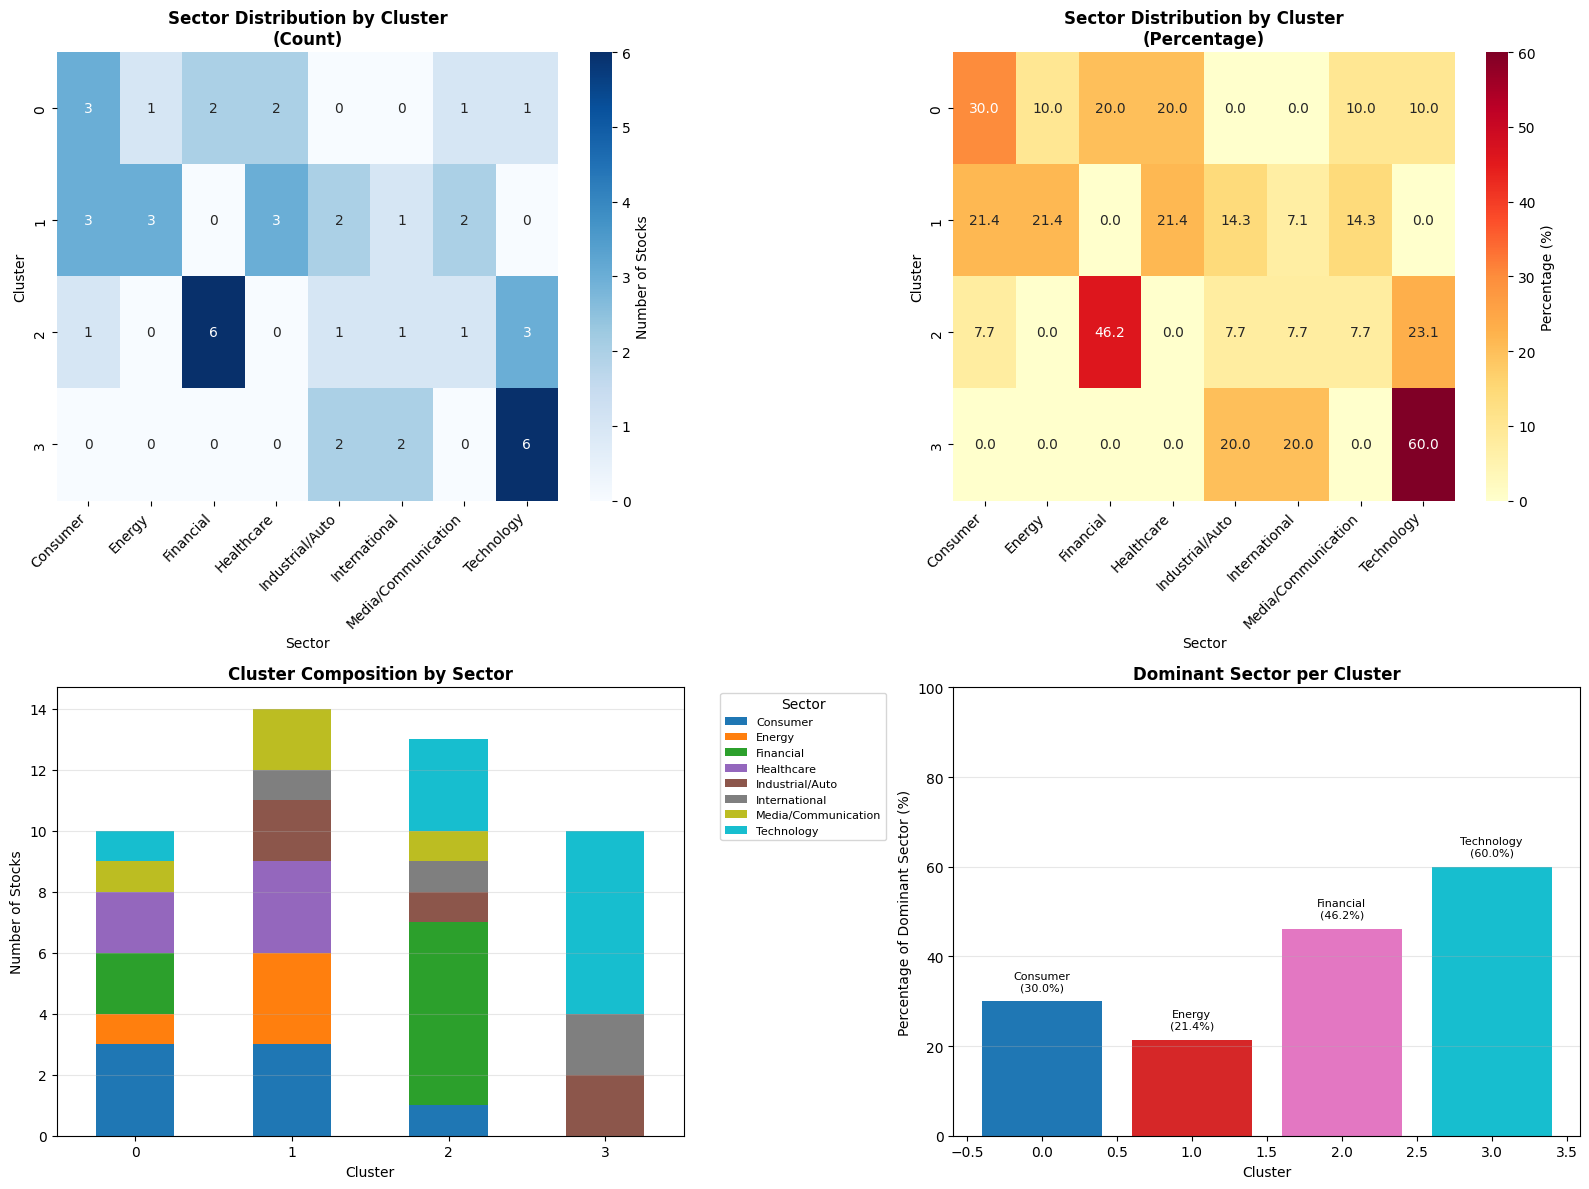


DETAILED CLUSTER ANALYSIS

Cluster 0 (10 stocks):
  Tickers: ABBV, COST, CVX, HD, JNJ, KO, MA, MSFT, T, V
  Sector distribution:
    Consumer                 :  3 stocks ( 30.0%)
    Healthcare               :  2 stocks ( 20.0%)
    Financial                :  2 stocks ( 20.0%)
    Energy                   :  1 stocks ( 10.0%)
    Technology               :  1 stocks ( 10.0%)
    Media/Communication      :  1 stocks ( 10.0%)
  Cluster Purity: 30.0%

Cluster 1 (14 stocks):
  Tickers: BA, CMCSA, COP, DIS, F, LLY, MRK, NEE, PEP, PFE, PG, TGT, TM, XOM
  Sector distribution:
    Energy                   :  3 stocks ( 21.4%)
    Healthcare               :  3 stocks ( 21.4%)
    Consumer                 :  3 stocks ( 21.4%)
    Industrial/Auto          :  2 stocks ( 14.3%)
    Media/Communication      :  2 stocks ( 14.3%)
    International            :  1 stocks (  7.1%)
  Cluster Purity: 21.4%

Cluster 2 (13 stocks):
  Tickers: AAPL, AXP, BAC, CSCO, GM, GS, HSBC, IBM, JPM, MS, NFLX, WFC, WM

{'comparison_df':    ticker  cluster               sector
 0    AAPL        2           Technology
 1    ABBV        0           Healthcare
 2    AMZN        3           Technology
 3     AXP        2            Financial
 4      BA        1      Industrial/Auto
 5    BABA        3        International
 6     BAC        2            Financial
 7     CAT        3      Industrial/Auto
 8   CMCSA        1  Media/Communication
 9     COP        1               Energy
 10   COST        0             Consumer
 11   CSCO        2           Technology
 12    CVX        0               Energy
 13    DIS        1  Media/Communication
 14      F        1      Industrial/Auto
 15     GM        2      Industrial/Auto
 16  GOOGL        3           Technology
 17     GS        2            Financial
 18     HD        0             Consumer
 19   HSBC        2        International
 20    IBM        2           Technology
 21   INTC        3           Technology
 22    JNJ        0           Healthcare

In [130]:
compare_clusters_with_sectors(global_data['cluster'], global_data['ticker'])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. HIERARCHICAL CLUSTERING (Dendrogram)
# ============================================

def hierarchical_clustering_analysis(data, tickers, max_k=10, linkage_method='ward', output_dir='ml/data/clustering'):
    """
    Use hierarchical clustering dendrogram to find natural groupings.
    
    Args:
        data: Feature matrix (n_samples, n_features)
        tickers: Array of ticker symbols
        max_k: Maximum number of clusters to test
        linkage_method: 'ward', 'complete', 'average', 'single'
        output_dir: Output directory
    """
    print("="*80)
    print("HIERARCHICAL CLUSTERING ANALYSIS")
    print("="*80)
    
    # Calculate linkage matrix
    if linkage_method == 'ward':
        # Ward requires Euclidean distance
        linkage_matrix = linkage(data, method='ward')
    else:
        # Other methods can use different distance metrics
        distances = pdist(data, metric='euclidean')
        linkage_matrix = linkage(distances, method=linkage_method)
    
    # Plot full dendrogram
    plt.figure(figsize=(20, 10))
    dendrogram(
        linkage_matrix,
        labels=tickers if len(tickers) <= 50 else None,  # Only show labels if not too many
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=None  # Show all levels
    )
    plt.title(f'Hierarchical Clustering Dendrogram ({linkage_method} linkage)', fontsize=14, fontweight='bold')
    plt.xlabel('Stock Ticker', fontsize=12)
    plt.ylabel('Distance', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/hierarchical_dendrogram_full.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Test different k values and calculate metrics
    print(f"\nTesting k from 2 to {max_k}...")
    print(f"{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18}")
    print("-" * 60)
    
    results = []
    for k in range(2, max_k + 1):
        labels = fcluster(linkage_matrix, k, criterion='maxclust')
        
        # Calculate metrics
        silhouette = silhouette_score(data, labels)
        db_score = davies_bouldin_score(data, labels)
        ch_score = calinski_harabasz_score(data, labels)
        
        # Cluster sizes
        cluster_sizes = np.bincount(labels)
        
        results.append({
            'k': k,
            'silhouette': silhouette,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'cluster_sizes': cluster_sizes
        })
        
        print(f"{k:<5} {silhouette:<12.4f} {db_score:<15.4f} {ch_score:<18.4f}")
        print(f"      Cluster sizes: {cluster_sizes}")
    
    results_df = pd.DataFrame(results)
    
    # Find optimal k
    optimal_k_sil = int(results_df.loc[results_df['silhouette'].idxmax(), 'k'])
    optimal_k_db = int(results_df.loc[results_df['davies_bouldin'].idxmin(), 'k'])
    
    print(f"\nRecommended k (Silhouette): {optimal_k_sil}")
    print(f"Recommended k (Davies-Bouldin): {optimal_k_db}")
    
    # Visualize metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(results_df['k'], results_df['silhouette'], marker='o', linewidth=2, markersize=8)
    axes[0].axvline(x=optimal_k_sil, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_sil}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Hierarchical: Silhouette Score')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(results_df['k'], results_df['davies_bouldin'], marker='o', linewidth=2, markersize=8, color='orange')
    axes[1].axvline(x=optimal_k_db, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_db}')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Davies-Bouldin Score')
    axes[1].set_title('Hierarchical: Davies-Bouldin Score')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    axes[2].plot(results_df['k'], results_df['calinski_harabasz'], marker='o', linewidth=2, markersize=8, color='green')
    axes[2].set_xlabel('Number of Clusters (k)')
    axes[2].set_ylabel('Calinski-Harabasz Score')
    axes[2].set_title('Hierarchical: Calinski-Harabasz Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/hierarchical_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'linkage_matrix': linkage_matrix,
        'results_df': results_df,
        'optimal_k_silhouette': optimal_k_sil,
        'optimal_k_db': optimal_k_db
    }

# ============================================
# 2. GAP STATISTIC
# ============================================

def gap_statistic(data, k_max=10, n_refs=10, random_state=42):
    """
    Calculate Gap Statistic to find optimal number of clusters.
    
    Gap Statistic compares the total within intra-cluster variation for different
    values of k with their expected values under null reference distribution.
    
    Args:
        data: Feature matrix
        k_max: Maximum number of clusters to test
        n_refs: Number of reference datasets to generate
        random_state: Random seed
        
    Returns:
        Dictionary with gap values and optimal k
    """
    print("="*80)
    print("GAP STATISTIC ANALYSIS")
    print("="*80)
    print("This may take a while... Generating reference distributions...")
    
    np.random.seed(random_state)
    
    gaps = []
    sk_values = []
    k_range = range(1, k_max + 1)
    
    for k in k_range:
        # Fit clustering on actual data
        if k == 1:
            # For k=1, Wk is just total variance
            wk = np.sum((data - data.mean(axis=0))**2)
        else:
            kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            kmeans.fit(data)
            wk = kmeans.inertia_
        
        # Generate reference datasets and calculate Wkb
        wk_refs = []
        for _ in range(n_refs):
            # Generate random reference data (uniform distribution within bounding box)
            random_data = np.random.uniform(
                low=data.min(axis=0),
                high=data.max(axis=0),
                size=data.shape
            )
            
            if k == 1:
                wk_ref = np.sum((random_data - random_data.mean(axis=0))**2)
            else:
                kmeans_ref = KMeans(n_clusters=k, random_state=None, n_init=10)
                kmeans_ref.fit(random_data)
                wk_ref = kmeans_ref.inertia_
            
            wk_refs.append(wk_ref)
        
        # Calculate Gap statistic
        gap = np.log(np.mean(wk_refs)) - np.log(wk)
        gaps.append(gap)
        
        # Calculate standard error
        sk = np.std(np.log(wk_refs)) * np.sqrt(1 + 1/n_refs)
        sk_values.append(sk)
        
        print(f"k={k:2d}: Gap={gap:.4f}, sk={sk:.4f}")
    
    gaps = np.array(gaps)
    sk_values = np.array(sk_values)
    
    # Find optimal k: smallest k such that Gap(k) >= Gap(k+1) - s(k+1)
    optimal_k = 1
    for k in range(len(gaps) - 1):
        if gaps[k] >= gaps[k + 1] - sk_values[k + 1]:
            optimal_k = k + 1
            break
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gap statistic plot
    axes[0].plot(k_range, gaps, marker='o', linewidth=2, markersize=8, label='Gap(k)')
    axes[0].errorbar(k_range, gaps, yerr=sk_values, fmt='none', alpha=0.5, label='±sk')
    axes[0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Gap Statistic')
    axes[0].set_title('Gap Statistic (Higher is Better)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Gap(k) - Gap(k+1) + s(k+1) plot
    gap_diff = []
    for k in range(len(gaps) - 1):
        diff = gaps[k] - (gaps[k + 1] - sk_values[k + 1])
        gap_diff.append(diff)
    
    axes[1].plot(list(k_range)[1:], gap_diff, marker='o', linewidth=2, markersize=8, color='green')
    axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k}')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Gap(k) - [Gap(k+1) - s(k+1)]')
    axes[1].set_title('Gap Statistic Criterion')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('ml/data/clustering/gap_statistic.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nOptimal k (Gap Statistic): {optimal_k}")
    
    return {
        'gaps': gaps,
        'sk_values': sk_values,
        'optimal_k': optimal_k,
        'k_range': list(k_range)
    }

# ============================================
# 3. WSS (Within Sum of Squares) - Elbow Method
# ============================================

def wss_elbow_method(data, k_max=10, random_state=42, method='kmeans'):
    """
    Calculate Within Sum of Squares (WSS) / Inertia for Elbow Method.
    
    Args:
        data: Feature matrix
        k_max: Maximum number of clusters
        random_state: Random seed
        method: 'kmeans' or 'pam'
        
    Returns:
        Dictionary with WSS values and optimal k
    """
    print("="*80)
    print("WSS (ELBOW METHOD) ANALYSIS")
    print("="*80)
    
    k_range = range(1, k_max + 1)
    wss_values = []
    
    print(f"{'k':<5} {'WSS (Inertia)':<15} {'WSS Decrease':<15} {'% Decrease':<15}")
    print("-" * 60)
    
    for k in k_range:
        if method == 'kmeans':
            model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        else:  # PAM
            model = KMedoids(n_clusters=k, metric='euclidean', random_state=random_state)
        
        model.fit(data)
        wss = model.inertia_
        wss_values.append(wss)
        
        # Calculate decrease from previous k
        if k > 1:
            wss_decrease = wss_values[-2] - wss
            pct_decrease = (wss_decrease / wss_values[-2]) * 100
            print(f"{k:<5} {wss:<15.2f} {wss_decrease:<15.2f} {pct_decrease:<15.2f}%")
        else:
            print(f"{k:<5} {wss:<15.2f} {'-':<15} {'-':<15}")
    
    wss_values = np.array(wss_values)
    
    # Calculate rate of change (second derivative approximation)
    # Elbow is where the rate of decrease slows down significantly
    wss_decrease_rate = np.diff(wss_values)
    wss_decrease_rate2 = np.diff(wss_decrease_rate)  # Second derivative
    
    # Find elbow: maximum of second derivative (where decrease rate changes most)
    if len(wss_decrease_rate2) > 0:
        optimal_k_elbow = np.argmax(wss_decrease_rate2) + 2  # +2 because we start from k=1
    else:
        optimal_k_elbow = 2
    
    # Alternative: Find k where decrease is less than threshold
    pct_decreases = []
    for i in range(1, len(wss_values)):
        pct_decrease = ((wss_values[i-1] - wss_values[i]) / wss_values[i-1]) * 100
        pct_decreases.append(pct_decrease)
    
    # Find where percentage decrease drops below threshold (e.g., 5%)
    threshold = 5.0
    optimal_k_threshold = 2
    for i, pct in enumerate(pct_decreases):
        if pct < threshold:
            optimal_k_threshold = i + 2
            break
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # WSS plot (Elbow curve)
    axes[0].plot(k_range, wss_values, marker='o', linewidth=2, markersize=8, color='blue')
    axes[0].axvline(x=optimal_k_elbow, color='r', linestyle='--', alpha=0.5, label=f'Elbow k={optimal_k_elbow}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('WSS (Within Sum of Squares)')
    axes[0].set_title(f'WSS Elbow Method ({method.upper()})')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Rate of change
    axes[1].plot(list(k_range)[1:], wss_decrease_rate, marker='o', linewidth=2, markersize=8, color='orange')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('WSS Decrease Rate')
    axes[1].set_title('First Derivative (Rate of Change)')
    axes[1].grid(True, alpha=0.3)
    
    # Second derivative
    if len(wss_decrease_rate2) > 0:
        axes[2].plot(list(k_range)[2:], wss_decrease_rate2, marker='o', linewidth=2, markersize=8, color='green')
        axes[2].axvline(x=optimal_k_elbow, color='r', linestyle='--', alpha=0.5, label=f'Elbow k={optimal_k_elbow}')
        axes[2].set_xlabel('Number of Clusters (k)')
        axes[2].set_ylabel('Change in Decrease Rate')
        axes[2].set_title('Second Derivative (Elbow Detection)')
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()
    
    plt.tight_layout()
    plt.savefig(f'ml/data/clustering/wss_elbow_{method}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nOptimal k (Elbow method): {optimal_k_elbow}")
    print(f"Optimal k (Threshold method, <{threshold}% decrease): {optimal_k_threshold}")
    
    return {
        'wss_values': wss_values,
        'k_range': list(k_range),
        'optimal_k_elbow': optimal_k_elbow,
        'optimal_k_threshold': optimal_k_threshold,
        'pct_decreases': pct_decreases
    }

# ============================================
# 4. PAIRWISE SUPPORT & PAIRWISE SUPPORT GLOBAL
# ============================================

def pairwise_support(data, labels, n_iterations=100, random_state=42):
    """
    Calculate Pairwise Support metrics for cluster stability.
    
    Pairwise Support: For each pair of points, how often are they in the same cluster
    across multiple runs? Measures cluster stability.
    
    Args:
        data: Feature matrix
        labels: Cluster labels from a single run
        n_iterations: Number of bootstrap iterations
        random_state: Random seed
        
    Returns:
        Dictionary with pairwise support metrics
    """
    print("="*80)
    print("PAIRWISE SUPPORT ANALYSIS")
    print("="*80)
    print(f"Running {n_iterations} bootstrap iterations...")
    
    np.random.seed(random_state)
    n_samples = len(data)
    n_clusters = len(np.unique(labels))
    
    # Create co-occurrence matrix
    cooccurrence_matrix = np.zeros((n_samples, n_samples))
    
    for iteration in range(n_iterations):
        # Bootstrap sample (sample with replacement)
        bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        bootstrap_data = data[bootstrap_indices]
        
        # Cluster bootstrap data
        kmeans = KMeans(n_clusters=n_clusters, random_state=None, n_init=10)
        bootstrap_labels = kmeans.fit_predict(bootstrap_data)
        
        # Map bootstrap labels back to original indices
        # (This is approximate - bootstrap indices may have duplicates)
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                orig_i = bootstrap_indices[i]
                orig_j = bootstrap_indices[j]
                
                # If both points are in bootstrap sample and in same cluster
                if bootstrap_labels[i] == bootstrap_labels[j]:
                    cooccurrence_matrix[orig_i, orig_j] += 1
                    cooccurrence_matrix[orig_j, orig_i] += 1
        
        if (iteration + 1) % 20 == 0:
            print(f"  Completed {iteration + 1}/{n_iterations} iterations...")
    
    # Normalize to get probabilities
    pairwise_support_matrix = cooccurrence_matrix / n_iterations
    
    # Calculate pairwise support for original clustering
    original_same_cluster = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            if labels[i] == labels[j]:
                original_same_cluster[i, j] = 1
    
    # Pairwise Support: Average probability that pairs in same cluster stay together
    same_cluster_pairs = []
    different_cluster_pairs = []
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            support = pairwise_support_matrix[i, j]
            if labels[i] == labels[j]:
                same_cluster_pairs.append(support)
            else:
                different_cluster_pairs.append(support)
    
    pairwise_support_same = np.mean(same_cluster_pairs) if same_cluster_pairs else 0
    pairwise_support_diff = np.mean(different_cluster_pairs) if different_cluster_pairs else 0
    
    # Pairwise Support Global: Overall stability
    # Higher when same-cluster pairs have high support and different-cluster pairs have low support
    pairwise_support_global = pairwise_support_same - pairwise_support_diff
    
    print(f"\nPairwise Support (same cluster pairs): {pairwise_support_same:.4f}")
    print(f"Pairwise Support (different cluster pairs): {pairwise_support_diff:.4f}")
    print(f"Pairwise Support Global: {pairwise_support_global:.4f} (higher is better)")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original clustering
    im1 = axes[0].imshow(original_same_cluster, cmap='RdYlGn', aspect='auto')
    axes[0].set_title('Original Clustering\n(1 = same cluster, 0 = different)')
    axes[0].set_xlabel('Stock Index')
    axes[0].set_ylabel('Stock Index')
    plt.colorbar(im1, ax=axes[0])
    
    # Pairwise support matrix
    im2 = axes[1].imshow(pairwise_support_matrix, cmap='viridis', aspect='auto')
    axes[1].set_title('Pairwise Support Matrix\n(Probability of being in same cluster)')
    axes[1].set_xlabel('Stock Index')
    axes[1].set_ylabel('Stock Index')
    plt.colorbar(im2, ax=axes[1])
    
    plt.tight_layout()
    plt.savefig('ml/data/clustering/pairwise_support.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'pairwise_support_same': pairwise_support_same,
        'pairwise_support_diff': pairwise_support_diff,
        'pairwise_support_global': pairwise_support_global,
        'pairwise_support_matrix': pairwise_support_matrix,
        'cooccurrence_matrix': cooccurrence_matrix
    }

def pairwise_support_multiple_k(data, k_range, n_iterations=50, random_state=42):
    """
    Calculate Pairwise Support Global for multiple k values to find optimal k.
    
    Args:
        data: Feature matrix
        k_range: Range of k values to test
        n_iterations: Number of bootstrap iterations (reduced for speed)
        random_state: Random seed
        
    Returns:
        Dictionary with pairwise support global for each k
    """
    print("="*80)
    print("PAIRWISE SUPPORT GLOBAL (Multiple k)")
    print("="*80)
    print("This will take a while...")
    
    results = []
    
    for k in k_range:
        print(f"\nTesting k={k}...")
        
        # Get base clustering
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        base_labels = kmeans.fit_predict(data)
        
        # Calculate pairwise support
        ps_result = pairwise_support(data, base_labels, n_iterations=n_iterations, 
                                     random_state=random_state + k)
        
        results.append({
            'k': k,
            'pairwise_support_global': ps_result['pairwise_support_global'],
            'pairwise_support_same': ps_result['pairwise_support_same'],
            'pairwise_support_diff': ps_result['pairwise_support_diff']
        })
        
        print(f"  Pairwise Support Global: {ps_result['pairwise_support_global']:.4f}")
    
    results_df = pd.DataFrame(results)
    
    # Find optimal k (highest pairwise support global)
    optimal_k = int(results_df.loc[results_df['pairwise_support_global'].idxmax(), 'k'])
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(results_df['k'], results_df['pairwise_support_global'], 
                 marker='o', linewidth=2, markersize=8, color='blue')
    axes[0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5, 
                    label=f'Optimal k={optimal_k}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Pairwise Support Global')
    axes[0].set_title('Pairwise Support Global (Higher is Better)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(results_df['k'], results_df['pairwise_support_same'], 
                 marker='o', linewidth=2, markersize=8, color='green', label='Same cluster')
    axes[1].plot(results_df['k'], results_df['pairwise_support_diff'], 
                 marker='s', linewidth=2, markersize=8, color='red', label='Different cluster')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Pairwise Support')
    axes[1].set_title('Pairwise Support Components')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('ml/data/clustering/pairwise_support_multiple_k.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nOptimal k (Pairwise Support Global): {optimal_k}")
    
    return {
        'results_df': results_df,
        'optimal_k': optimal_k
    }

# ============================================
# COMPREHENSIVE COMPARISON
# ============================================

def comprehensive_optimal_k_analysis(data, tickers, k_max=10, output_dir='ml/data/clustering'):
    """
    Run all methods and compare results.
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE OPTIMAL K ANALYSIS")
    print("="*80)
    
    results_summary = []
    
    # 1. Hierarchical
    print("\n[1/5] Running Hierarchical Clustering...")
    hier_results = hierarchical_clustering_analysis(data, tickers, max_k=k_max, output_dir=output_dir)
    results_summary.append({
        'method': 'Hierarchical (Silhouette)',
        'optimal_k': hier_results['optimal_k_silhouette']
    })
    results_summary.append({
        'method': 'Hierarchical (DB)',
        'optimal_k': hier_results['optimal_k_db']
    })
    
    # 2. Gap Statistic
    print("\n[2/5] Running Gap Statistic...")
    gap_results = gap_statistic(data, k_max=k_max, n_refs=10)
    results_summary.append({
        'method': 'Gap Statistic',
        'optimal_k': gap_results['optimal_k']
    })
    
    # 3. WSS Elbow (K-Means)
    print("\n[3/5] Running WSS Elbow Method (K-Means)...")
    wss_kmeans = wss_elbow_method(data, k_max=k_max, method='kmeans')
    results_summary.append({
        'method': 'WSS Elbow (K-Means)',
        'optimal_k': wss_kmeans['optimal_k_elbow']
    })
    
    # 4. WSS Elbow (PAM)
    print("\n[4/5] Running WSS Elbow Method (PAM)...")
    wss_pam = wss_elbow_method(data, k_max=k_max, method='pam')
    results_summary.append({
        'method': 'WSS Elbow (PAM)',
        'optimal_k': wss_pam['optimal_k_elbow']
    })
    
    # 5. Pairwise Support (single k test - can be slow, so optional)
    print("\n[5/5] Running Pairwise Support Global (Multiple k)...")
    print("Note: This is computationally expensive. Consider reducing n_iterations.")
    ps_results = pairwise_support_multiple_k(data, range(2, min(k_max+1, 8)), 
                                             n_iterations=30)  # Reduced for speed
    results_summary.append({
        'method': 'Pairwise Support Global',
        'optimal_k': ps_results['optimal_k']
    })
    
    # Summary
    summary_df = pd.DataFrame(results_summary)
    
    print("\n" + "="*80)
    print("SUMMARY: OPTIMAL K BY METHOD")
    print("="*80)
    print(summary_df.to_string(index=False))
    
    # Most common optimal k
    mode_k = summary_df['optimal_k'].mode()
    if len(mode_k) > 0:
        print(f"\nMost common optimal k: {mode_k[0]}")
        print(f"Average optimal k: {summary_df['optimal_k'].mean():.1f}")
        print(f"Median optimal k: {summary_df['optimal_k'].median():.1f}")
    
    return {
        'summary': summary_df,
        'hierarchical': hier_results,
        'gap': gap_results,
        'wss_kmeans': wss_kmeans,
        'wss_pam': wss_pam,
        'pairwise_support': ps_results
    }

# ============================================
# USAGE EXAMPLE
# ============================================

# Run comprehensive analysis
# comprehensive_results = comprehensive_optimal_k_analysis(
#     data=global_scaled[numeric_cols].values,  # or global_pca
#     tickers=tickers,
#     k_max=10,
#     output_dir='ml/data/clustering'
# )

# Or run individual methods:
# hier_results = hierarchical_clustering_analysis(global_pca, tickers, max_k=10)
# gap_results = gap_statistic(global_pca, k_max=10)
# wss_results = wss_elbow_method(global_pca, k_max=10, method='pam')
# ps_results = pairwise_support_multiple_k(global_pca, range(2, 8), n_iterations=30)

In [156]:
comprehensive_results = comprehensive_optimal_k_analysis(
    data=global_scaled[numeric_cols].values,  # or global_pca
    tickers=tickers,
    k_max=10
)


COMPREHENSIVE OPTIMAL K ANALYSIS

[1/5] Running Hierarchical Clustering...
HIERARCHICAL CLUSTERING ANALYSIS


KeyError: -8

<Figure size 2000x1000 with 0 Axes>